# GIAI ĐOẠN 2: DATA CLEANING & PREPROCESSING
Mục tiêu:: Biến dữ liệu thô từ nhiều nguồn khác nhau thành dữ liệu sạch sẵn sàng cho phân tích và huấn luyện mô hình
**Quy trình xử lý**
1. **Ingestion & Merging:** Gộp dữ liệu đa luồng 
2. **Data Profiling:** Soi dữ liệu
3. **Standardization:** Chuẩn hoá định dạng văn bản
3. **Extraction:** Trích xuất đặc trưng(Quận/Huyện,Thông tin nột thất, tiền dịch vụ...)
4. **Cleaning Logic:** Xử lý trùng lặp, dữ liệu khuyết, các cột không liên quan đến bài toán và Outliers
5. **Enrichment:** Phân vùng địa lý(Zoning)

In [37]:
import pandas as pd
import numpy as np
import csv
import re # Thư viện xử lý Regular Expression (Regex)
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

INPUT_FILES = [
    '../../data/raw/homedy_raw.csv',
    '../../data/raw/phongtro123_raw.csv',
    '../../data/raw/tromoi_raw.csv',
    '../../data/raw/chotot_raw.csv'
]

OUTPUT_FILE = '../../data/processed/clean_data_file.csv'

print('Đã import thư viện và cấu hình xong')

Đã import thư viện và cấu hình xong


## Bước 1: Data Ingestion & Merging (Gộp dữ liệu)
Chúng ta load tất cả các file csv thô, đổi tên cột về chuấn tiếng anh(optional), và gộp lại

In [38]:
def load_and_merge(file_list):
    all_dfs = []
    for f in file_list:
        try:
            # load dữ liệu
            df = pd.read_csv(f)
            # kiểm tra nhanh file có đủ cột không
            required_cols = ['title', 'price', 'area', 'address', 'description']
            if not all(col in df.columns for col in required_cols):
                print(f"Cảnh báo: File {f} thiếu cột chuẩn. Bỏ qua.")
                continue
            
            all_dfs.append(df)
            print(f"-> Đã load {f}: {len(df)} dòng")
        except Exception as e:
            print(f"Lỗi đọc file {f}: {e}")
    
    if not all_dfs: return None
    
    # gộp
    df_master = pd.concat(all_dfs, ignore_index= True)
    
    # Bỏ cột index thừa (vì pandas khi read_csv sẽ tự tạo index mới)
    if 'index' in df_master.columns:
        df_master = df_master.drop(columns=['index'])
    
    return df_master

# chạy load 
df = load_and_merge(INPUT_FILES)
print(f"TỔNG DỮ LIỆU: {len(df)} dòng")
display(df.head(2))

-> Đã load ../../data/raw/homedy_raw.csv: 1944 dòng
-> Đã load ../../data/raw/phongtro123_raw.csv: 12000 dòng
-> Đã load ../../data/raw/tromoi_raw.csv: 711 dòng
-> Đã load ../../data/raw/chotot_raw.csv: 20032 dòng
TỔNG DỮ LIỆU: 34687 dòng


,url,title,price,area,address,description,source,posted_time,owner_name,phone
0,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/chdv-30m2-gac-cao-cua...,"CHDV 30m2 gác cao cửa sổ lớn đường Giải Phóng Tân Bình chỉ 5,5 triệu","5,5 Triệu/tháng",30 m2,"Đường Giải Phóng, Phường 4, Quận Tân Bình, TP Hồ Chí Minh",CHÍNH CHỦ CHO THUÊ CHDV ĐƯỜNG GIẢI PHÓNG TÂN BÌNH CÓ GÁC CHỈ 5 TRIỆU 500k - Địa chỉ: Đường Giải...,homedy.com,NaN,NaN,NaN
1,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/con-duy-nhat-1-duong-...,"Còn duy nhất 1 phòng cho thuê_ Đường Hoàng Văn Thụ, P.2, Q. Tân Bình, Hồ Chí Minh","3,5 Triệu/tháng",26 m2,"Đường Hoàng Văn Thụ, Phường 2, Quận Tân Bình, TP Hồ Chí Minh","Khu dân cư yên tĩnh, an ninh, ngay vòng xoay Lăng Cha Cả. Thuận tiện di chuyển muôn nơi (3-5 phú...",homedy.com,NaN,NaN,NaN


## Bước 2: Data profiling(Soi dữ liệu)

Mục tiêu: Tìm ra format lạ để viết hàm xử lý cho đúng<div>

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34687 entries, 0 to 34686
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          34687 non-null  object 
 1   title        34687 non-null  object 
 2   price        34687 non-null  object 
 3   area         34686 non-null  object 
 4   address      34675 non-null  object 
 5   description  34675 non-null  object 
 6   source       34687 non-null  object 
 7   posted_time  12000 non-null  object 
 8   owner_name   12000 non-null  object 
 9   phone        12000 non-null  float64
dtypes: float64(1), object(9)
memory usage: 2.6+ MB


In [40]:
def inspect_data_by_source(df, col_name):
    print(f"\n=== KIỂM TRA CỘT: {col_name.upper()} ===")
    
    sources = df['source'].unique()
    for source in sources:
        print(f"\nNGUỒN: {source}")
        # 1. Lọc lấy dữ liệu của riêng nguồn này
        df_source = df[df['source']== source]
        
        # 2. Tìm các giá trị khả nghi chứa chữ cái
        weird_values = df_source[df_source[col_name].astype(str).str.contains(r'[a-zA-Z]', na=False)]
    
        # 3. Lấy danh sách các kiểu viết lạ(Unique)
        unique_weird = weird_values[col_name].unique()
        
        # 4. In ra kế quả (Chỉ in tối đa 10 mẫu)
        if len(unique_weird) > 0:
            print(f"   - Phát hiện {len(weird_values)} dòng chứa chữ.")
            print(f"   - Các mẫu format lạ (Top 10):")
            print(f"     {unique_weird[:10]}") # In 10 mẫu đầu tiên của nguồn này
        else:
            print(f"   - Sạch (Chỉ toàn số hoặc NaN).")
    
        # 5. Soi chi tiết từng độ dài (Step-by-step scan)
        s_values = df_source[col_name].dropna().astype(str)
        
        if len(s_values) > 0:
            lengths = s_values.str.len()
            min_len = int(lengths.min())
            max_len = int(lengths.max())
            
            print(f"   - Độ dài chuỗi: Min={min_len}, Max={max_len}")
            
            # Nếu khoảng cách Min-Max quá lớn (ví dụ > 50), chỉ in những độ dài có dữ liệu để tránh spam
            # Nếu khoảng cách nhỏ (ví dụ 12-20), in full như ý bạn
            range_len = range(min_len, max_len + 1)
            
            # Chỉ in tối đa 30 dòng để tránh treo máy nếu có outlier (VD: Min=5, Max=1000)
            if max_len - min_len > 30:
                print(f"     (Khoảng cách quá lớn, chỉ in các độ dài có xuất hiện dữ liệu...)")
                scan_list = sorted(lengths.unique()) # Chỉ lấy các độ dài có thật
            else:
                scan_list = range_len # Quét full từ Min đến Max (kể cả rỗng)

            for l in scan_list:
                # Tìm label (Min/Max)
                label = f"Mẫu {l}"
                if l == min_len: label += "(Min)"
                elif l == max_len: label += "(Max)"
                
                # Lấy 3 mẫu unique
                samples = s_values[lengths == l].unique()[:3].tolist()
                
                # In ra (Chỉ in nếu có dữ liệu hoặc nếu đang ở chế độ quét full)
                if len(samples) > 0:
                    print(f"     + {label:<15}: {samples}")
                elif max_len - min_len <= 30: # Nếu list rỗng nhưng nằm trong range nhỏ thì vẫn in []
                     print(f"     + {label:<15}: []")

        else:
             print("   - (Không có dữ liệu)")
        
        
             
inspect_data_by_source(df, 'price')
inspect_data_by_source(df, 'area')        


=== KIỂM TRA CỘT: PRICE ===

NGUỒN: homedy.com
   - Phát hiện 1944 dòng chứa chữ.
   - Các mẫu format lạ (Top 10):
     ['5,5 Triệu/tháng' '3,5 Triệu/tháng' '4,5 Triệu/tháng' '1,4 Triệu/tháng'
 '0,75 Triệu/tháng' '1,2 Triệu/tháng' '1 Triệu/tháng'
 '3,5 - 5 Triệu/tháng' '3,8 - 5 Triệu/tháng' '4,8 Triệu/tháng']
   - Độ dài chuỗi: Min=4, Max=23
     + Mẫu 4(Min)     : ['7 Tỷ']
     + Mẫu 5          : []
     + Mẫu 6          : []
     + Mẫu 7          : ['10,3 Tỷ']
     + Mẫu 8          : []
     + Mẫu 9          : []
     + Mẫu 10         : ['Thỏa thuận']
     + Mẫu 11         : []
     + Mẫu 12         : []
     + Mẫu 13         : ['1 Triệu/tháng', '4 Triệu/tháng', '3 Triệu/tháng']
     + Mẫu 14         : ['15 Triệu/tháng', '10 Triệu/tháng', '12 Triệu/tháng']
     + Mẫu 15         : ['5,5 Triệu/tháng', '3,5 Triệu/tháng', '4,5 Triệu/tháng']
     + Mẫu 16         : ['0,75 Triệu/tháng', '0,95 Triệu/tháng', '0,65 Triệu/tháng']
     + Mẫu 17         : ['6 - 9 Triệu/tháng', '3 - 5 Triệu/thán

**3 Phát hiện quan trọng từ dữ liệu:**<div>
1. Xung đột dấu thập phân:
- homedy: 5,5 Triệu
- phongtro123: 9.5 triệu
- phongtro123: 5.000.000 đồng 
2. Xuất hiện khoảng giá trị 7 - 15 m2, 6 - 9 Triệu/tháng 
3. Dữ liệu rỗng: m2 mà không có số phía trước
4. xuất hiện mẫu lạ 'Thoả thuận'
<div>


## BƯỚC 3: STANDARDIZATION


**Chiến thuật xử lý:**<div>
Bước 1 (Pre-clean): Nếu gặp nguồn homedy, thay thế ngay , thành .

Bước 2 (Phân loại dấu chấm):
Nếu chuỗi chứa "triệu" hoặc "tỷ" -> Dấu . là thập phân (Giữ nguyên)
Nếu chuỗi chứa "đồng" hoặc không có đơn vị -> Dấu . là hàng nghìn (Xóa đi)

Bước 3 (Range): Tách dấu -, tính trung bình cộng.


**Kết quả mong đợi với price**<div>
Input: 5,5 Triệu/tháng      -> Output: 5,500,000<div>
Input: 9.5 triệu/tháng      -> Output: 9,500,000<div>
Input: 5.000.000 đồng/tháng -> Output: 5,000,000<div>
Input: 3,5 - 5 Triệu/tháng  -> Output: 4,250,000<div>
Input: 5 đồng/tháng         -> Output: 5<div>
Input: 0,75 Triệu/tháng     -> Output: 750,000<div>
Input: 7 Tỷ                 -> Output: 7,000,000,000<div>

**Kết quả mong đợi với area**<div>
Input: 25 m2                 -> Output: 25 <div>
Input: 100m²                 -> Output: 100 <div>
Input: 8 - 10 m2             -> Output: 9 

In [41]:
def parse_price(price_raw):
    if pd.isna(price_raw): return np.nan
    s = str(price_raw).lower().strip()
    
    # 0. Check các trường hợp đặc biệt ngay từ đầu
    if 'thỏa thuận' in s or 'thoa thuan' in s: return np.nan
    
    # 1. Xác định "Ngữ cảnh toàn câu" (Global Context)
    # Để biết "3,5 - 5 Triệu" thì số 3,5 kia cũng phải là Triệu
    multiplier = 1
    has_explicit_unit = False # Cờ đánh dấu đã tìm thấy đơn vị to
    
    if 'tỷ' in s or 'ty' in s:
        multiplier = 1_000_000_000
        has_explicit_unit = True
    elif 'triệu' in s or 'tr' in s:
        multiplier = 1_000_000
        has_explicit_unit = True
    elif 'usd' in s:
        multiplier = 25_000
        has_explicit_unit = True
    elif 'ngàn' in s or 'k ' in s or s.endswith('k'): # k phải đứng riêng hoặc cuối câu
        multiplier = 1_000
        has_explicit_unit = True
        
    # 2. Check "Đơn vị nhỏ" (Đồng/VND) -> Để CHẶN heuristic nhân triệu
    is_small_unit = False
    if 'đồng' in s or 'đ/' in s or 'vnd' in s or 'uud' in s: # uud do lỗi font
        is_small_unit = True

    # 3. Chuẩn hóa dấu phẩy (5,5 -> 5.5)
    s = s.replace(',', '.')

    # 4. Hàm con: Tách số từ 1 đoạn text con
    def extract_number(sub_s):
        # Xóa các dấu chấm phân cách hàng nghìn nếu đó là đơn vị nhỏ
        # VD: 5.000.000 đồng -> 5000000
        if is_small_unit or (not has_explicit_unit and sub_s.count('.') >= 2):
            sub_s = sub_s.replace('.', '')
            
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", sub_s)
        if nums:
            val = float(nums[0])
            
            # LOGIC QUYẾT ĐỊNH HỆ SỐ NHÂN (QUAN TRỌNG NHẤT)
            # Nếu đã xác định được Global Unit (Triệu/Tỷ) -> Nhân luôn
            if has_explicit_unit:
                # Nhưng nếu số đã quá lớn (VD: user nhập 3.000.000 triệu) -> thì không nhân nữa
                if val > 1000 and multiplier >= 1_000_000:
                    return val 
                return val * multiplier
            
            # Nếu KHÔNG có đơn vị to, và KHÔNG phải đơn vị nhỏ (đồng)
            # Thì mới áp dụng Heuristic < 1000 => Nhân triệu
            if not is_small_unit and val < 1000:
                return val * 1_000_000
                
            return val
        return None

    # 5. Xử lý Range (3.5 - 5)
    if '-' in s:
        parts = s.split('-')
        if len(parts) >= 2:
            v1 = extract_number(parts[0])
            v2 = extract_number(parts[1])
            
            # Nếu tách được cả 2 thì lấy trung bình
            if v1 is not None and v2 is not None:
                return (v1 + v2) / 2
            # Nếu chỉ tách được 1 số (số kia rác)
            return v1 if v1 is not None else v2

    # 6. Xử lý số đơn
    return extract_number(s)

# --- CHẠY LẠI TEST CASE CỦA BẠN (ĐỂ KIỂM CHỨNG) ---
test_cases = [
    '5,5 Triệu/tháng',      
    '9.5 triệu/tháng',      
    '5.000.000 đồng/tháng', 
    '3,5 - 5 Triệu/tháng',  # Ca khó nhất
    '5 đồng/tháng',         # Ca bị lỗi cũ
    '0,75 Triệu/tháng',     
    '7 Tỷ'                 
]

print("KẾT QUẢ LOGIC:")
for t in test_cases:
    val = parse_price(t)
    print(f"Input: {t:<22} -> Output: {val:,.0f}" if pd.notna(val) else f"Input: {t:<22} -> Output: NaN")
    
def parse_area(area_raw):
    """
    Xử lý: '30m2', '30 - 40m2', '4x15', '5*20'
    """
    if pd.isna(area_raw): return np.nan
    s = str(area_raw).lower().strip()
    
    # 0. Nếu không có số nào -> NaN (VD: chỉ có chữ 'm2')
    if not any(char.isdigit() for char in s):
        return np.nan

    # 1. Dọn dẹp đơn vị và dấu phẩy
    s = s.replace('m²', '').replace('m2', '').replace('s', '') # Có nơi viết 30s (square)
    s = s.replace(',', '.') 

    # 2. Xử lý Kích thước Dài x Rộng (4x15 hoặc 4*15)
    # Logic: Nếu thấy dấu x hoặc *, tách ra và nhân lại
    if 'x' in s or '*' in s:
        # Chuẩn hóa về 'x'
        s_dim = s.replace('*', 'x')
        parts = s_dim.split('x')
        if len(parts) >= 2:
            try:
                # Tìm số trong từng phần (VD: "4m" x "15m")
                v1 = float(re.findall(r"[\d.]+", parts[0])[0])
                v2 = float(re.findall(r"[\d.]+", parts[1])[0])
                return v1 * v2 # Trả về diện tích tính toán
            except:
                pass # Nếu lỗi thì xuống bước dưới xử lý bình thường

    # 3. Xử lý Range (30 - 45) -> Trung bình cộng
    if '-' in s:
        parts = s.split('-')
        if len(parts) >= 2:
            try:
                v1 = float(re.findall(r"[\d.]+", parts[0])[0])
                v2 = float(re.findall(r"[\d.]+", parts[1])[0])
                return (v1 + v2) / 2
            except: 
                pass

    # 4. Tách số đơn thuần
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", s)
    if nums:
        return float(nums[0])
        
    return np.nan

# --- CHẠY THỬ NGHIỆM CASE DIỆN TÍCH ---
test_area_cases = [
    '30 m2',
    '30 - 40 m2',     # Range
    '4x15',           # Dimension (Dài x Rộng)
    '5*20 m2',        # Dimension biến thể
    '15,5 m2',        # Dấu phẩy
    'm2'              # Rác
]

print("\nKIỂM TRA AREA:")
for t in test_area_cases:
    val = parse_area(t)
    print(f"Input: {t:<15} -> Output: {val}")


print(f"Dữ liệu trước khi chuẩn hóa: {df.shape}")

print("⏳ Đang chạy chuẩn hóa cột PRICE...")
# Tạo cột mới 'price', giữ nguyên cột 'price_raw' để đối chiếu nếu cần
df['price'] = df['price'].apply(parse_price)

print("⏳ Đang chạy chuẩn hóa cột AREA...")
# Tạo cột mới 'area'
df['area'] = df['area'].apply(parse_area)

print("✅ Đã chuẩn hóa xong!")


KẾT QUẢ LOGIC:
Input: 5,5 Triệu/tháng        -> Output: 5,500,000
Input: 9.5 triệu/tháng        -> Output: 9,500,000
Input: 5.000.000 đồng/tháng   -> Output: 5,000,000
Input: 3,5 - 5 Triệu/tháng    -> Output: 4,250,000
Input: 5 đồng/tháng           -> Output: 5
Input: 0,75 Triệu/tháng       -> Output: 750,000
Input: 7 Tỷ                   -> Output: 7,000,000,000

KIỂM TRA AREA:
Input: 30 m2           -> Output: 30.0
Input: 30 - 40 m2      -> Output: 35.0
Input: 4x15            -> Output: 60.0
Input: 5*20 m2         -> Output: 100.0
Input: 15,5 m2         -> Output: 15.5
Input: m2              -> Output: nan
Dữ liệu trước khi chuẩn hóa: (34687, 10)
⏳ Đang chạy chuẩn hóa cột PRICE...
⏳ Đang chạy chuẩn hóa cột AREA...
✅ Đã chuẩn hóa xong!


## BƯỚC 4: Extraction
 

Loại bỏ số nhà của đường

In [42]:
def clean_street_reverse(text):
    """
    Quét từ cuối về đầu:
    - Khi gặp chữ cái => kích hoạt
    - Khi đã kích hoạt mà gặp ký tự KHÔNG phải chữ => cắt chuỗi tại đó
    """
    space_activated=False
    activated = False
    cut=False
    cut_pos = None

    for i in range(len(text) - 1, -1, -1):
        ch = text[i]
        #Nếu là khoảng trắng
        if ch.isspace():
            space_activated=True
            cut_pos = i
            continue
        # Nếu là chữ cái Unicode (mọi ngôn ngữ)
        if ch.isalpha() and space_activated:
            activated = True
            continue
        # Khi đã kích hoạt mà gặp ký tự 'không phải chữ'
        if activated:
            if not ch.isalpha() and not ch.isspace():
                cut=True
                break
    # Nếu có vị trí cần cắt
    if cut:
        return text[cut_pos+1:].strip()

    return text.strip()
def clean_parentheses(text):
    '''
    Loại bỏ toàn bộ nội dung trong ngoặc và bản thân dấu ngoặc
    '''
    return re.sub(r"\s*\([^)]*\)", "", text).strip()

def merge_lists(a, b):
    return [x if not pd.isna(x) else y for x, y in zip(a, b)]

#Hàm tìm input trong text, tìm được thì xóa toàn bộ nội dung sau từ đó lẫn từ đó, ví dụ, Quốc Ca Việt Nam, thì input=Ca thì xóa từ Ca ở sau
def clean_after_input_completely(text, input_str):
    if pd.isna(text):
        return text
    index = text.rfind(input_str)
    if index != -1:
        return text[:index].strip()
    return text.strip()
def clean_after_input(text, input_str):
    if pd.isna(text):
        return text

    index = text.rfind(input_str)
    if index != -1:
        return (text[:index] + text[index + len(input_str):]).strip()
    return text.strip()

#Hàm tìm keyword
def extract_first_match(text, keywords):
    if text is None:
        return None, None

    text_cleaned = text
    for kw in keywords:
        if kw in text_cleaned:
            return kw, clean_after_input(text_cleaned, kw)

    return None, text_cleaned

In [43]:

#viết thường toàn bộ kí tự của df["address"]
df["address"]=df["address"].str.lower()
df["description"]=df["description"].str.lower()
df["true_address"]=df["address"]
df["address"] = df["address"].astype(str)
#df['address'] = df['address'].apply(lambda x: x.split(', Việt Nam')[0] if pd.notna(x) and ', Việt Nam' in x else x)
#Xóa các từ gây nhiễu ở địa chỉ
df["address"] = df["address"].apply(clean_parentheses)

In [44]:
# Danh sách quận, phường ---
district_list = [
    "quận 10","quận 11","quận 12",
    "q10","q11","q12",
    "q. 10","q. 11","q. 12",
    "quận 1","quận 2","quận 3","quận 4","quận 5","quận 6","quận 7",
    "quận 8","quận 9",
    "q. 1","q. 2","q. 3","q. 4","q. 5","q. 6","q. 7",
    "q. 8","q. 9",
    "q1","q2","q3","q4","q5","q6","q7",
    "q8","q9",
    "bình thạnh","gò vấp","tân bình",
    "bình tân",
    "thủ đức",
    "bình chánh","hóc môn","củ chi",
    "cần giờ","nhà bè","phu nhuan","phú nhuận","tân phú"
]

ward_list = [
    # --- Ưu tiên 1: Hậu tố A, B ---
    "phước long b", "tăng nhơn phú a", "bình trị đông b", "an lạc a", 
    "bình hưng hòa b", "bình trị đông a", "bình hưng hòa a", "tân tạo a", 
    "vĩnh lộc a", "vĩnh lộc b", "phước long a", "tăng nhơn phú b",
    "binh hưng hoà a", "binh hưng hoà b",

    # --- Ưu tiên 2: Hậu tố Đông, Tây, Nam, Bắc ---
    "tân thuận tây", "an phú đông", "bình trưng tây", "tân thuận đông", 
    "bình trưng đông", "an lợi đông", "linh đông", "an thới đông", 
    "an hội đông", "an hội tây", "tân thạnh đông", "tân thạnh tây", 
    "xuân thới đông",

    # --- Các phường còn lại ---
     "phường 10", "phường 11", "phường 12", 
    "phường 13", "phường 14", "phường 15", "phường 16", "phường 17", "phường 18", 
    "phường 19", "phường 20", "phường 21", "phường 22", "phường 23", "phường 24", 
    "phường 25", "phường 26", "phường 27", "phường 28", 
    "phường10", "phường11", "phường12", 
    "phường13", "phường14", "phường15", "phường16", "phường17", "phường18", 
    "phường19", "phường20", "phường21", "phường22", "phường23", "phường24", 
    "phường25", "phường26", "phường27", "phường28", 
     "p10", 
    "p11", "p12", "p13", "p14", "p15", "p16", "p17", "p18", "p19", "p20", 
    "p21", "p22", "p23", "p24", "p25", "p26", "p27", "p28",
    ", 10", 
    ", 11,", ", 12,", ", 13,", ", 14,", ", 15,", ", 16,", ", 17,", ", 18", ", 19", ", 20", 
    ", 21,", ", 22,", ", 23,", ", 24,", ", 25,", ", 26,", ", 27,", ", 28,",
    "phường 1", "phường 2", "phường 3", "phường 4", "phường 5", "phường 6", 
    "phường 7", "phường 8", "phường 9",
    "phường1", "phường2", "phường3", "phường4", "phường5", "phường6", 
    "phường7", "phường8", "phường9",
    "p1", "p2", "p3", "p4", "p5", "p6", "p7", "p8", "p9",
    ", 1,", ", 2,", ", 3,", ", 4,", ", 5,", ", 6,", ", 7,", ", 8,", ", 9,", 
    "tân hưng", "tam bình", "tân định", "thạnh xuân", "bình hưng", "nhơn đức", 
    "hiệp phước", "bình khánh", "thủ thiêm", "thảo điền", "an khánh", "an phú", 
    "an lạc", "phú nhuận", "tân phú", "thạnh lộc", "bến thành", "cầu ông lãnh", 
    "an phú tây", "bình hưng hòa", "sơn kỳ", "tân tạo", "bình trị đông", 
    "thạnh mỹ lợi", "cát lái", "thới an", "phú hữu", "trường thạnh", "đa kao", 
    "tân kiểng", "bình thuận", "tân quy", "phường nguyễn cư trinh", "xã bà điểm", 
    "hiệp bình chánh", "phú thuận", "tây thạnh", "bến nghé", "nguyễn thái bình", 
    "phạm ngũ lão", "nguyễn cư trinh", "cầu kho", "cô giang", "võ thị sáu", 
    "tân kiên", "phú mỹ", "tân phong", "long trường", "long phước", "phước bình", 
    "tam phú", "linh trung", "linh xuân", "long thạnh mỹ", "hiệp phú", 
    "tân thới nhất", "tân hưng thuận", "đông hưng thuận", "tân chánh hiệp", 
    "trung mỹ tây", "hiệp thành", "tân thới hiệp", "tân sơn hòa", "tân sơn nhất", 
    "tân hòa", "bảy hiền", "tân bình", "tân sơn", "tân thành", "phú thọ hòa", 
    "phú trung", "hòa thạnh", "tân thới hòa", "hiệp tân", "phú thạnh", 
    "gia định", "bình thạnh", "bình lợi trung", "thạnh mỹ tây", "bình quới", 
    "hạnh thông", "an nhơn", "gò vấp", "thông tây hội", "hiệp bình phước", 
    "bình thọ", "linh chiểu", "trường thọ", "linh tây", "bình chiểu", 
    "xóm củi", "rạch ông", "hưng phú", "bình lợi", "tân túc", "tân nhật", 
    "bình chánh", "đa phước", "qui đức", "hưng long", "phong phú", 
    "tam thôn hiệp", "long hòa", "cần thạnh", "tân phú trung", "tân thông hội", 
    "phước vĩnh an", "phước hiệp", "tân an hội", "trung lập thượng", "phước thạnh", 
    "thái mỹ", "phú mỹ hưng", "nhơn tây", "phạm văn cội", "trung lập hạ", 
    "nhuận đức", "tân thạnh đông", "phú hòa đông", "bình mỹ", "hòa phú", 
    "trung an", "thới tam thôn", "nhị bình", "đông thạnh", "tân hiệp", 
    "tân xuân", "hóc môn", "tân thới nhì", "xuân thới sơn", "xuân thới thượng", 
    "trung chánh", "bà điểm", "nhà bè", "phú xuân", "phước kiển", "phước lộc", 
    "long thới", "thạnh an","tân quý","bình an","quy đức",
    "p.1","p.2","p.3","p.4","p.5","p.6","p.7","p.8","p.9","p.10",
    "p.11","p.12","p.13","p.14","p.15","p.16","p.17","p.18","p.19","p.20",
    "p.21","p.22","p.23","p.24","p.25","p.26","p.27","p.28","long bình","tân nhựt","phạm văn hai" ,"long bình","củ chi",
    "phú thọ hoà","hoà thạnh","sơn kì","lê minh xuân"
]

In [45]:
# --- Extract quận ---
districts_found = []
cleaned_address = []

for addr in df["address"]:
    district, rest = extract_first_match(addr, district_list)
    districts_found.append(district)
    cleaned_address.append(rest)

df["district"] = districts_found
df["address"] = cleaned_address

# --- Extract phường ---
wards_found = []
cleaned_address = []

for addr in df["address"]:
    wards, rest = extract_first_match(addr, ward_list)
    wards_found.append(wards)
    cleaned_address.append(rest)

df["ward"] = wards_found
df["address"] = cleaned_address



# --- Làm sạch dấu phẩy và khoảng trắng ---
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "quận"))
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "xã"))
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "tp"))
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "phường"))
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "thành phố"))
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "việt nam"))
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "hồ chí minh"))
df["address"]=df["address"].apply(lambda x: clean_after_input_completely(x, "hcm"))
df["address"] = df["address"].str.replace(",", " ", regex=False)
df["address"] = df["address"].str.replace(".", " ", regex=False)

df["address"] = df["address"].apply(lambda x: x.replace(" tháng ", "/").strip() if pd.notna(x) else x)
# --- Còn lại là street ---
def clean_street_remove_duong(text):
    if text is None:
        return None

    text = str(text).strip().lower()

    # tìm vị trí xuất hiện cuối cùng của từ "đường"
    pos = text.rfind("đường")

    if pos != -1:
        # cắt từ sau chữ "đường"
        text = text[pos + len("đường"):].strip()

    # xóa dấu ":" hoặc "-" đầu câu nếu có
    text = re.sub(r"^[\s\-\:\,]+", "", text)

    return text
df["street"] = df["address"].apply(clean_street_reverse)
#Xóa chữ "đường" trong df["street"], và xóa mọi kí tự trước đường
df["street"] = df["street"].apply(clean_street_remove_duong)
df["street"] = df["street"].apply(lambda x: x.replace("phố", "").strip() if pd.notna(x) else x)
df["street"] = df["street"].apply(lambda x: x.replace("số ", "").strip() if pd.notna(x) else x)
df["address"] = df["address"].str.replace("\s+", " ", regex=True).str.strip()
#Xóa df có df["district"] là NaN
df["address"]=df["true_address"]
#xóa true_address
df = df.drop(columns=["true_address"])
df = df[pd.notna(df["district"])]

#Chỉnh lại đúng format
df['district'] = df['district'].str.replace(r'(?i)^(?:quận|q)\.?\s*(\d+)$', r'\1', regex=True)
df['ward'] = df['ward'].str.replace(r'(?i)^[\W_]*(?:phường|p)?[\W_]*(\d+).*$', r'\1', regex=True)
df['ward'] = df['ward'].str.replace('phường','')

In [46]:
#in ra số lượng missing sau khi làm sạch
missing_district = df['district'].isna().sum()
missing_ward = df['ward'].isna().sum()
print(f"Số dòng missing district sau làm sạch: {missing_district}")
print(f"Số dòng missing ward sau làm sạch: {missing_ward}")

Số dòng missing district sau làm sạch: 0
Số dòng missing ward sau làm sạch: 1575


In [47]:
def apply_comprehensive_extraction(df):
    print("Bắt đầu trích xuất đặc trưng tổng hợp...")

    text_source = (df['title'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
    df['mention_electric_price'] = np.where(
    text_source.str.contains(r'điện|dien', case=False, na=False), 
    True, None
)

    df['mention_water_price'] = np.where(
        text_source.str.contains(r'nước|nuoc', case=False, na=False), 
        True, None
    )

    df['mention_service_price'] = np.where(
        text_source.str.contains(r'dịch vụ|dich vu|rác|rac|ql|phi chung|phí chung', case=False, na=False), 
        True, None
    )

    amenities_keywords = {
        'has_air_conditioner': r'máy lạnh|điều hòa|điều hoà|aircon|air conditioner|dieu hoa|may lanh',
        'has_kitchen': r'bếp|bếp riêng|bếp chung|khu bếp|bep',
        'has_fridge': r'tủ lạnh|tu lanh',
        'has_wardrobe': r'tủ quần áo|tu quan ao|tủ đồ|tủ áo|tu do|tu ao',
        'has_bed': r'giường|giuong',
        'has_mattress': r'nệm|nem|đệm',
        'has_sofa': r'sofa|ghế sofa|salon',
        'is_full_furniture': r'nội thất đầy đủ|full nội thất|đầy đủ nội thất|full nt|nội thất đẹp|full đồ|noi that day du|noi that dep',
        'is_duplex': r'gác|gác lửng|gac lung|duplex|gác xép|gac',
        'has_window': r'cửa sổ|cua so|cửa kính|cua kinh',
        'has_camera': r'camera|giám sát|giam sat|theo dõi|theo doi',
        'has_security': r'an ninh|bảo vệ|bao ve|khu an ninh|bảo vệ 24/7',
        'is_free_time': r'giờ giấc tự do|tu do gio giac|không chung chủ|riêng biệt|không giới hạn giờ|khong chung chu|ko chung chu',
        'near_school': r'gần trường|đại học|đh|cao đẳng|cách trường',
        'near_market': r'gần chợ|cách chợ|khu chợ',
        'near_supermarket': r'gần siêu thị|coopmart|big c|vinmart|aeon|tttm|lotte',
        'has_wifi': r'wifi|wi-fi|internet|mạng miễn phí|internet miễn phí|mang mien phi|có internet|co internet',
        'has_parking': r'chỗ để xe|bãi xe|giữ xe|đậu xe|gửi xe|hầm xe',
        'has_balcony': r'ban công|ban cong|balcony|lô gia'
    }

    for col, pattern in amenities_keywords.items():
        # Sử dụng (?<!không\s) để tránh bắt các cụm "không máy lạnh", "không chung chủ"
        final_pattern = fr'(?<!không\s)(?<!ko\s)(?:{pattern})'
        df[col] = text_source.str.contains(final_pattern, regex=True, na=False)

    # 3. TRÍCH XUẤT PHÂN LOẠI (Categorical)
    
    # Máy giặt: Riêng / Chung / Không có
    def get_washing_machine(text):
        if 'máy giặt riêng' in text or 'may giat rieng' in text or 'máy giặt trong phòng' in text or 'may giat trong phong' in text: return 'private'
        if 'máy giặt chung' in text or 'may giat chung' in text or 'chung may giat' in text or 'máy giặt' in text or 'may giat' in text: return 'share'
        return None
    
    # WC: Riêng / Chung / Không có
    def get_wc_type(text):
        if 'wc riêng' in text or 'nhà vệ sinh riêng' in text or 'wc trong phòng' in text or 'nha ve sinh rieng' in text: return 'private'
        if 'nha ve sinh trong' in text or 'nhà vệ sinh trong' in text: 'private'
        if 'wc chung' in text or 'nhà vệ sinh chung' in text or 'wc' in text or 'nhà vệ sinh chung' in text: return 'share'
        return None
    # Loại khóa: Vân tay / Từ / Khác
    def get_lock_type(text):
        if any(kw in text for kw in ['vân tay', 'van tay']): return 'fingerprint'
        if any(kw in text for kw in ['khóa từ', 'khoa tu', 'thẻ từ']): return 'card'
        if any(kw in text for kw in ['không khóa', 'không có khóa']): return 'none'
        return None
    def get_water_type(text):
        if any(kw in text for kw in ['nước máy', 'nuoc may']): return 'tap'
        if any(kw in text for kw in ['nước giếng', 'nuoc gieng']): return 'well'
        if any(kw in text for kw in ['nước bình', 'nước lọc', 'ro', 'nuoc binh']): return 'bottle'
        return None

    # Phân vùng địa lý (Area Group - Từ extract_feature)
    def map_district_to_area(district):
        if pd.isna(district): return 'unknown'
        d = str(district).lower()
        if any(x in d for x in ['1', '3', '4', '5']) and '12' not in d: return 'center'
        if any(x in d for x in ['10', '11', 'tân bình', 'phú nhuận', 'bình thạnh']): return 'near_center'
        if any(x in d for x in ['2', '9', 'thủ đức']): return 'east'
        if any(x in d for x in ['6', 'bình tân', 'tân phú']): return 'west'
        if any(x in d for x in ['7', '8', 'nhà bè']): return 'south'
        if any(x in d for x in ['12', 'hóc môn', 'củ chi', 'bình chánh', 'cần giờ', 'gò vấp']): return 'outer'
        return 'unknown'

    df['washing_machine_type'] = text_source.apply(get_washing_machine)
    df['lock_type'] = text_source.apply(get_lock_type)
    df['wc_type'] = text_source.apply(get_wc_type)
    df['water_type'] = text_source.apply(get_water_type)
    df['area_group'] = df['district'].apply(map_district_to_area)

    print("Hoàn tất trích xuất đặc trưng!")
    return df

# Chạy hàm xử lý
df = apply_comprehensive_extraction(df)

Bắt đầu trích xuất đặc trưng tổng hợp...
Hoàn tất trích xuất đặc trưng!


In [48]:
#in ra danh sách cột của df sau khi làm sạch
print("Danh sách cột sau khi làm sạch và trích xuất đặc trưng:")
print(df.info())

Danh sách cột sau khi làm sạch và trích xuất đặc trưng:
<class 'pandas.core.frame.DataFrame'>
Index: 34663 entries, 0 to 34686
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     34663 non-null  object 
 1   title                   34663 non-null  object 
 2   price                   34609 non-null  float64
 3   area                    34661 non-null  float64
 4   address                 34663 non-null  object 
 5   description             34663 non-null  object 
 6   source                  34663 non-null  object 
 7   posted_time             11994 non-null  object 
 8   owner_name              11994 non-null  object 
 9   phone                   11994 non-null  float64
 10  district                34663 non-null  object 
 11  ward                    33088 non-null  object 
 12  street                  34663 non-null  object 
 13  mention_electric_price  12030 non-null  

# Exploratory Data Analysis (EDA) & Data Preprocessing
## HCM Rental Room Price Prediction

**Objective**: Phân tích dữ liệu một cách có hệ thống, phát hiện patterns, outliers, và preprocessing để tạo dataset sạch cho modeling.

**Workflow**:
1. Data Overview & Initial Assessment
2. Target Variable Analysis (Price)
3. Numerical Features Analysis
4. Categorical Features Analysis
5. Binary Features Analysis
6. Missing Data Handling
7. Outlier Detection & Treatment
8. Feature Engineering & Selection
9. Data Validation & Export

In [49]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Data Types:")
print(df.dtypes.value_counts())

# Display first few rows
print("\n🔍 First 3 rows:")
df.head(3)

DATASET OVERVIEW

📊 Shape: 34,663 rows × 40 columns

📋 Data Types:
bool       19
object     18
float64     3
Name: count, dtype: int64

🔍 First 3 rows:


,url,title,price,area,address,description,source,posted_time,owner_name,phone,district,ward,street,mention_electric_price,mention_water_price,mention_service_price,has_air_conditioner,has_kitchen,has_fridge,has_wardrobe,has_bed,has_mattress,has_sofa,is_full_furniture,is_duplex,has_window,has_camera,has_security,is_free_time,near_school,near_market,near_supermarket,has_wifi,has_parking,has_balcony,washing_machine_type,lock_type,wc_type,water_type,area_group
0,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/chdv-30m2-gac-cao-cua...,"CHDV 30m2 gác cao cửa sổ lớn đường Giải Phóng Tân Bình chỉ 5,5 triệu",5500000.00,30.00,"đường giải phóng, phường 4, quận tân bình, tp hồ chí minh",chính chủ cho thuê chdv đường giải phóng tân bình có gác chỉ 5 triệu 500k - địa chỉ: đường giải...,homedy.com,NaN,NaN,NaN,tân bình,4,giải phóng,True,True,True,True,True,True,True,True,True,False,False,True,True,True,True,True,False,False,False,False,False,False,share,fingerprint,None,None,near_center
1,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/con-duy-nhat-1-duong-...,"Còn duy nhất 1 phòng cho thuê_ Đường Hoàng Văn Thụ, P.2, Q. Tân Bình, Hồ Chí Minh",3500000.00,26.00,"đường hoàng văn thụ, phường 2, quận tân bình, tp hồ chí minh","khu dân cư yên tĩnh, an ninh, ngay vòng xoay lăng cha cả. thuận tiện di chuyển muôn nơi (3-5 phú...",homedy.com,NaN,NaN,NaN,tân bình,2,hoàng văn thụ,None,None,None,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,False,None,None,None,bottle,near_center
2,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-7-tp-ho-chi-minh/tang-1-152-duong-so-39-phuon...,"Cho thuê phòng tầng 1, 152 đường số 39, phường Tân Hưng, Tp.HCM",4500000.00,15.00,"đường số 39, phường tân hưng, quận 7, tp hồ chí minh","cho thuê phòng tầng 1, 152 đường số 39, phường tân hưng, tp.hcm phòng đã lắp sẵn máy lạnh, sạch ...",homedy.com,NaN,NaN,NaN,7,tân hưng,39,None,None,None,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,None,None,None,None,south


In [50]:
# Column categorization
numerical_cols = ['price', 'area']
categorical_cols = [
    'source', 'washing_machine_type', 'wc_type', 
    'lock_type', 'area_group', 'district', 'ward'
]
binary_cols = [
    'mention_dien', 'mention_nuoc', 'mention_dich_vu',
    'has_air_conditioner', 'has_kitchen', 'has_fridge', 'has_wardrobe', 
    'has_bed', 'has_mattress', 'has_sofa', 'is_full_furniture', 
    'is_duplex', 'has_window', 'has_camera', 'has_security', 
    'is_free_time', 'near_school', 'near_market', 'near_supermarket', 
    'has_wifi', 'has_parking', 'has_balcony'
]
text_cols = [
    'url', 'title', 'address', 'description', 'street', 
    'true_address', 'owner_name', 'phone', 'posted_time'
]

print("="*70)
print("FEATURE CATEGORIZATION")
print("="*70)
print(f"\n📊 Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"\n🏷️  Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"\n✅ Binary features ({len(binary_cols)}): {len(binary_cols)} features")
print(f"\n📝 Text features ({len(text_cols)}): {text_cols}")

FEATURE CATEGORIZATION

📊 Numerical features (2): ['price', 'area']

🏷️  Categorical features (7): ['source', 'washing_machine_type', 'wc_type', 'lock_type', 'area_group', 'district', 'ward']

✅ Binary features (22): 22 features

📝 Text features (9): ['url', 'title', 'address', 'description', 'street', 'true_address', 'owner_name', 'phone', 'posted_time']


## 2. Target Variable Analysis (Price)

TARGET VARIABLE: PRICE (VND)
Count.................... 34,609
Missing.................. 54 (0.16%)
Mean..................... 6,237,682
Median................... 3,800,000
Std Dev.................. 173,461,110
CV (%)................... 2780.9
Min...................... 0
Max...................... 24,000,000,000
Q1 (25%)................. 2,900,000
Q3 (75%)................. 4,800,000
IQR...................... 1,900,000


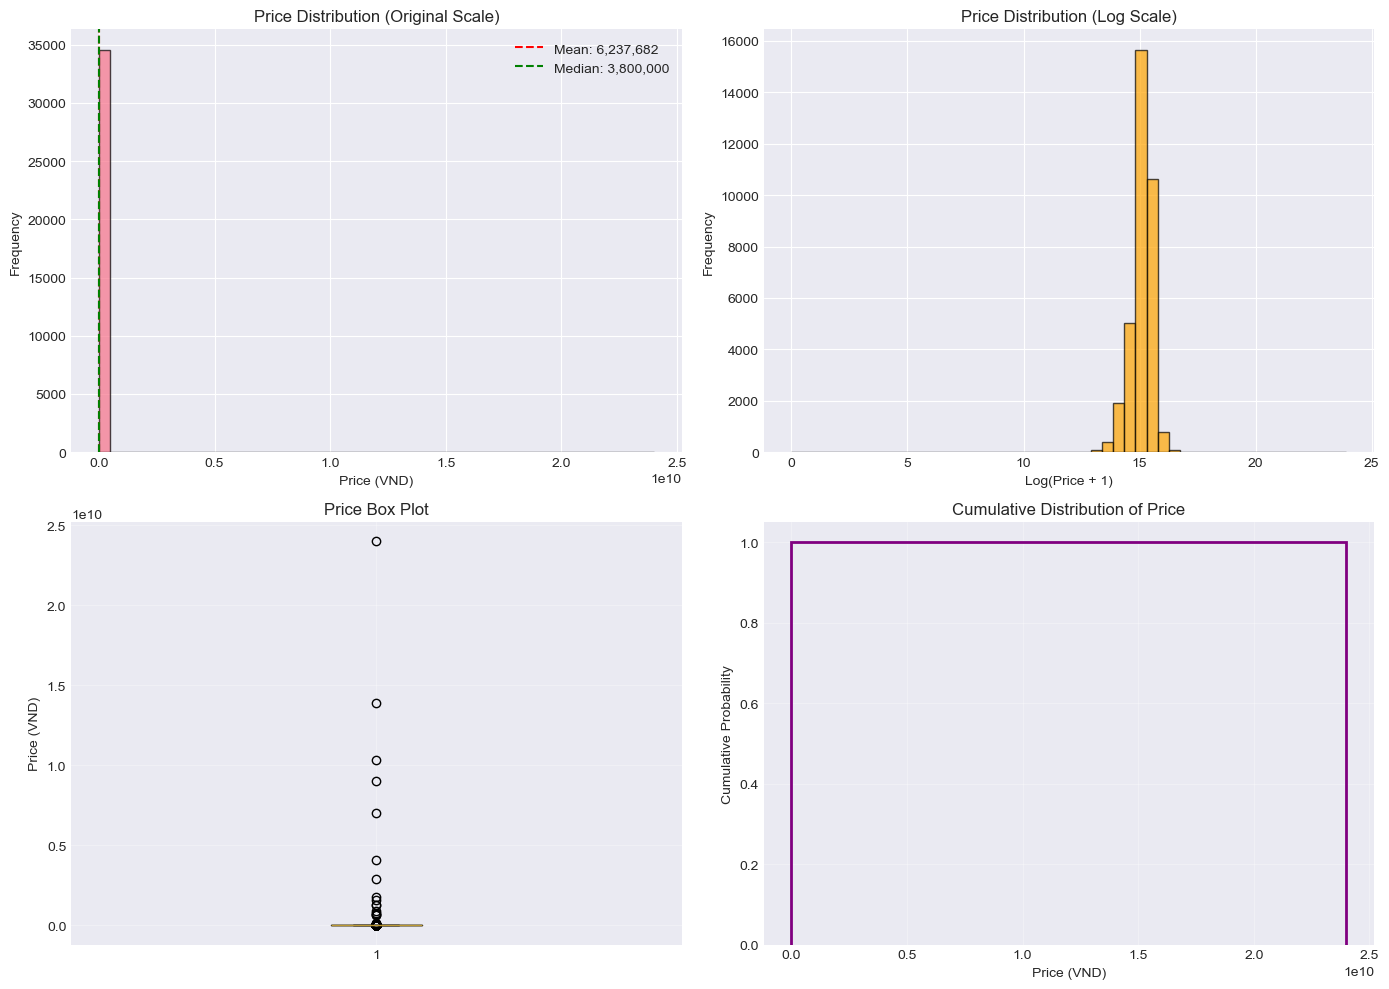


💡 Price Insights:
   • Mean > Median: Yes (right-skewed)
   • Price range spread: 24,000,000,000 VND
   • Coefficient of variation: 2780.9%


In [51]:
# Price statistics
print("="*70)
print("TARGET VARIABLE: PRICE (VND)")
print("="*70)

price_valid = df['price'].dropna()

stats_dict = {
    'Count': f"{len(price_valid):,}",
    'Missing': f"{df['price'].isnull().sum():,} ({df['price'].isnull().sum()/len(df)*100:.2f}%)",
    'Mean': f"{price_valid.mean():,.0f}",
    'Median': f"{price_valid.median():,.0f}",
    'Std Dev': f"{price_valid.std():,.0f}",
    'CV (%)': f"{(price_valid.std() / price_valid.mean() * 100):.1f}",
    'Min': f"{price_valid.min():,.0f}",
    'Max': f"{price_valid.max():,.0f}",
    'Q1 (25%)': f"{price_valid.quantile(0.25):,.0f}",
    'Q3 (75%)': f"{price_valid.quantile(0.75):,.0f}",
    'IQR': f"{price_valid.quantile(0.75) - price_valid.quantile(0.25):,.0f}"
}

for key, value in stats_dict.items():
    print(f"{key:.<25} {value}")

# Visualize price distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(price_valid, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Price (VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution (Original Scale)')
axes[0, 0].axvline(price_valid.mean(), color='red', linestyle='--', label=f'Mean: {price_valid.mean():,.0f}')
axes[0, 0].axvline(price_valid.median(), color='green', linestyle='--', label=f'Median: {price_valid.median():,.0f}')
axes[0, 0].legend()

# Log-scale histogram
axes[0, 1].hist(np.log1p(price_valid), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Log(Price + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Price Distribution (Log Scale)')

# Box plot
axes[1, 0].boxplot(price_valid, vert=True)
axes[1, 0].set_ylabel('Price (VND)')
axes[1, 0].set_title('Price Box Plot')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative distribution
axes[1, 1].hist(price_valid, bins=50, cumulative=True, density=True, 
                histtype='step', linewidth=2, color='purple')
axes[1, 1].set_xlabel('Price (VND)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of Price')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Price Insights:")
print(f"   • Mean > Median: {'Yes' if price_valid.mean() > price_valid.median() else 'No'} ({'right-skewed' if price_valid.mean() > price_valid.median() else 'left-skewed or symmetric'})")
print(f"   • Price range spread: {price_valid.max() - price_valid.min():,.0f} VND")
print(f"   • Coefficient of variation: {(price_valid.std() / price_valid.mean() * 100):.1f}%")

In [52]:
# Outlier detection for price using IQR method
Q1 = price_valid.quantile(0.25)
Q3 = price_valid.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print("="*70)
print("PRICE OUTLIER ANALYSIS (IQR Method)")
print("="*70)
print(f"\nLower bound: {lower_bound:,.0f} VND")
print(f"Upper bound: {upper_bound:,.0f} VND")
print(f"\nOutliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"\nPrice range of outliers:")
if len(outliers) > 0:
    print(f"   • Min: {outliers['price'].min():,.0f} VND")
    print(f"   • Max: {outliers['price'].max():,.0f} VND")
    print(f"   • Mean: {outliers['price'].mean():,.0f} VND")
    
# Show some outlier examples
if len(outliers) > 0:
    print(f"\n🔍 Sample outliers:")
    print(outliers[['price', 'area', 'district', 'is_full_furniture']].head(10))

PRICE OUTLIER ANALYSIS (IQR Method)

Lower bound: 50,000 VND
Upper bound: 7,650,000 VND

Outliers detected: 670 (1.93%)

Price range of outliers:
   • Min: 0 VND
   • Max: 24,000,000,000 VND
   • Mean: 130,427,590 VND

🔍 Sample outliers:
             price   area    district  is_full_furniture
17      8500000.00  40.00  bình thạnh              False
23      8500000.00  35.00  bình thạnh               True
56      8700000.00  45.00   phú nhuận               True
60      8200000.00  30.00  bình thạnh               True
100     8500000.00  20.00           1               True
116     7800000.00  35.00           7               True
190     8000000.00  55.00  bình thạnh              False
228 10300000000.00 253.00      nhà bè              False
271    15000000.00  60.00           3               True
276     8000000.00  25.00           3               True


## 3. Numerical Features Analysis

NUMERICAL FEATURES SUMMARY

📊 PRICE
Valid values: 34,609 | Missing: 54 (0.16%)
Range: [0, 24,000,000,000]
Mean: 6,237,682 | Median: 3,800,000 | Std: 173,461,110
CV: 2780.9%

📊 AREA
Valid values: 34,661 | Missing: 2 (0.01%)
Range: [0, 3,200,000]
Mean: 227 | Median: 25 | Std: 22,916
CV: 10109.3%

CORRELATION ANALYSIS


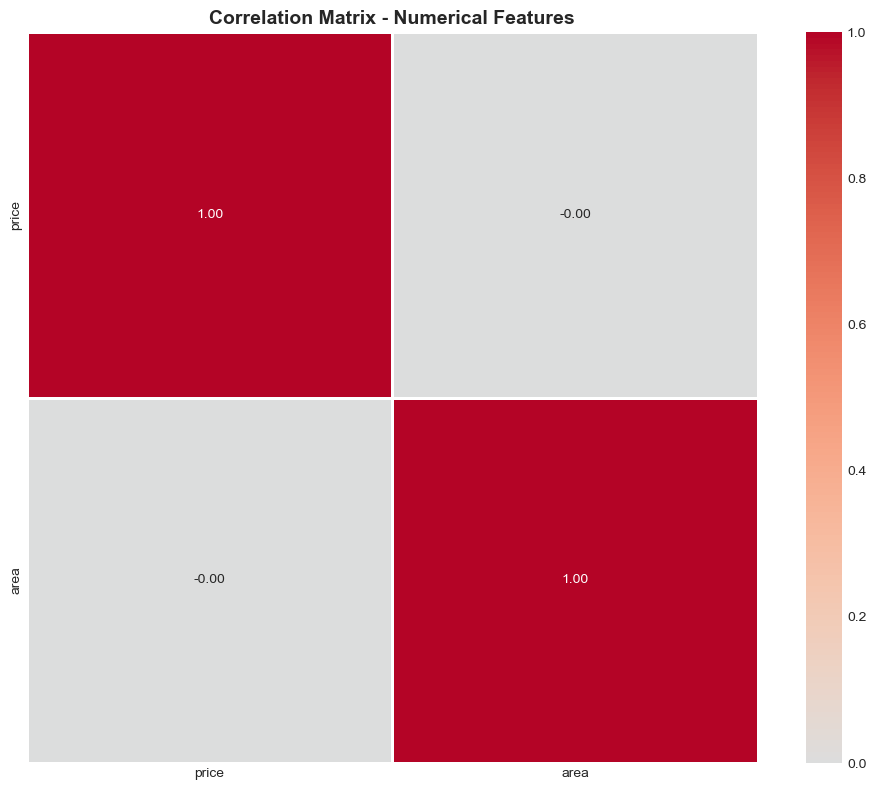


🎯 Correlations with Price:
   area..........................  -0.000


In [53]:
# Analyze all numerical features
print("="*70)
print("NUMERICAL FEATURES SUMMARY")
print("="*70)

for col in numerical_cols:
    if col in df.columns:
        valid_data = df[col].dropna()
        missing_pct = df[col].isnull().sum() / len(df) * 100
        
        print(f"\n{'='*70}")
        print(f"📊 {col.upper()}")
        print(f"{'='*70}")
        print(f"Valid values: {len(valid_data):,} | Missing: {df[col].isnull().sum():,} ({missing_pct:.2f}%)")
        
        if len(valid_data) > 0:
            print(f"Range: [{valid_data.min():,.0f}, {valid_data.max():,.0f}]")
            print(f"Mean: {valid_data.mean():,.0f} | Median: {valid_data.median():,.0f} | Std: {valid_data.std():,.0f}")
            print(f"CV: {(valid_data.std() / valid_data.mean() * 100):.1f}%")
            
            # Check for unrealistic values
            if col.endswith('_price'):
                unrealistic = valid_data[(valid_data < 1000) | (valid_data > 1000000)]
                if len(unrealistic) > 0:
                    print(f"⚠️  Warning: {len(unrealistic)} unrealistic values (< 1k or > 1M VND)")

# Correlation matrix for numerical features
print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

numeric_df = df[numerical_cols].dropna()
if len(numeric_df) > 0:
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show correlations with price
    price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
    print("\n🎯 Correlations with Price:")
    for feat, corr_val in price_corr.items():
        print(f"   {feat:.<30} {corr_val:>7.3f}")

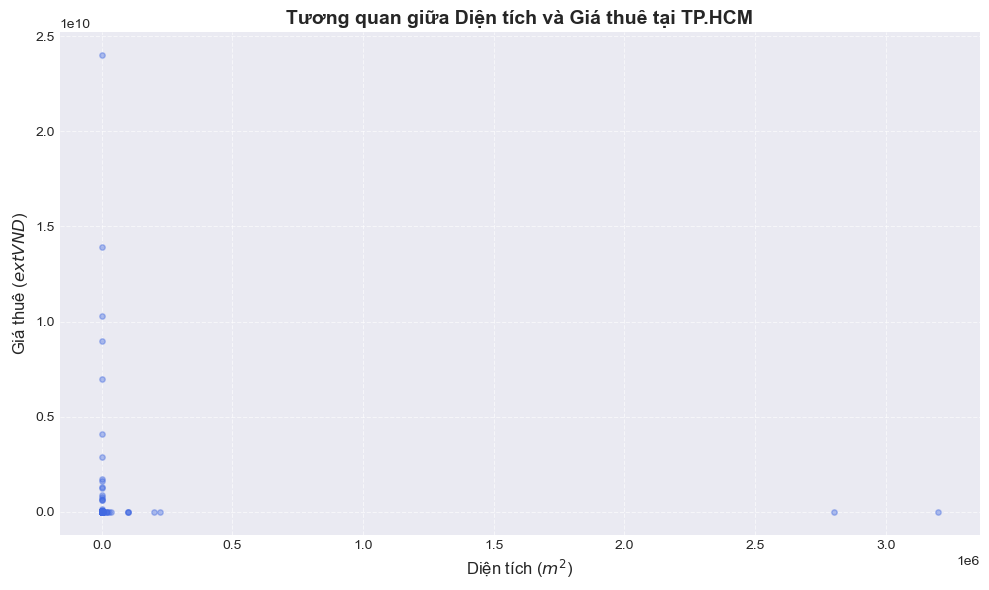

In [54]:
import matplotlib.pyplot as plt

# 1. Lọc dữ liệu không bị khuyết để tránh lỗi khi vẽ
valid_mask = df['area'].notna() & df['price'].notna()
valid_df = df[valid_mask]

# 2. Khởi tạo biểu đồ đơn
if len(valid_df) > 0:
    # Thiết kế kích thước biểu đồ
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Vẽ biểu đồ phân tán (Scatter plot)
    ax.scatter(valid_df['area'], valid_df['price'], alpha=0.4, s=15, color='royalblue')
    
    # Thiết lập nhãn và tiêu đề bằng tiếng Việt (có định dạng LaTeX cho đơn vị)
    ax.set_xlabel('Diện tích ($m^2$)', fontsize=12)
    ax.set_ylabel('Giá thuê ($\text{VND}$)', fontsize=12)
    ax.set_title('Tương quan giữa Diện tích và Giá thuê tại TP.HCM', fontsize=14, fontweight='bold')
    
    # Thêm lưới để dễ quan sát
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Tối ưu hóa khoảng cách
    plt.tight_layout()
    
    plt.show() # Bỏ comment nếu chạy trên máy cá nhân
else:
    print("Không có đủ dữ liệu hợp lệ để vẽ biểu đồ.")

## 4. Categorical Features Analysis

In [55]:
# Analyze categorical features
print("="*70)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*70)

cat_features_to_analyze = ['area_group', 'toilet_type', 'washing_machine_type', 'lock_type', 'water_type', 'source']

for col in cat_features_to_analyze:
    if col in df.columns:
        print(f"\n{'='*70}")
        print(f"🏷️  {col.upper()}")
        print(f"{'='*70}")
        
        value_counts = df[col].value_counts(dropna=False)
        missing_count = df[col].isnull().sum()
        
        print(f"Unique values: {df[col].nunique()}")
        print(f"Missing: {missing_count:,} ({missing_count/len(df)*100:.2f}%)")
        print(f"\nValue distribution:")
        
        for val, count in value_counts.items():
            pct = count / len(df) * 100
            print(f"   {str(val):.<35} {count:>6,} ({pct:>5.2f}%)")
        
        # Calculate mean price per category
        if len(df[df[col].notna()]) > 0:
            price_by_cat = df.groupby(col)['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
            print(f"\n💰 Price by {col}:")
            print(price_by_cat.to_string())

CATEGORICAL FEATURES ANALYSIS

🏷️  AREA_GROUP
Unique values: 7
Missing: 0 (0.00%)

Value distribution:
   near_center........................  9,928 (28.64%)
   east...............................  6,014 (17.35%)
   west...............................  5,581 (16.10%)
   outer..............................  5,065 (14.61%)
   center.............................  4,688 (13.52%)
   south..............................  3,386 ( 9.77%)
   unknown............................      1 ( 0.00%)

💰 Price by area_group:
                   mean     median  count
area_group                               
south       14178780.45 4000000.00   3370
outer       10528074.06 3500000.00   5061
center       5840647.15 4500000.00   4679
near_center  4500677.77 4500000.00   9908
east         4084292.77 3400000.00   6012
unknown      3500000.00 3500000.00      1
west         3287111.01 3300000.00   5578

🏷️  WASHING_MACHINE_TYPE
Unique values: 2
Missing: 24,636 (71.07%)

Value distribution:
   None..............

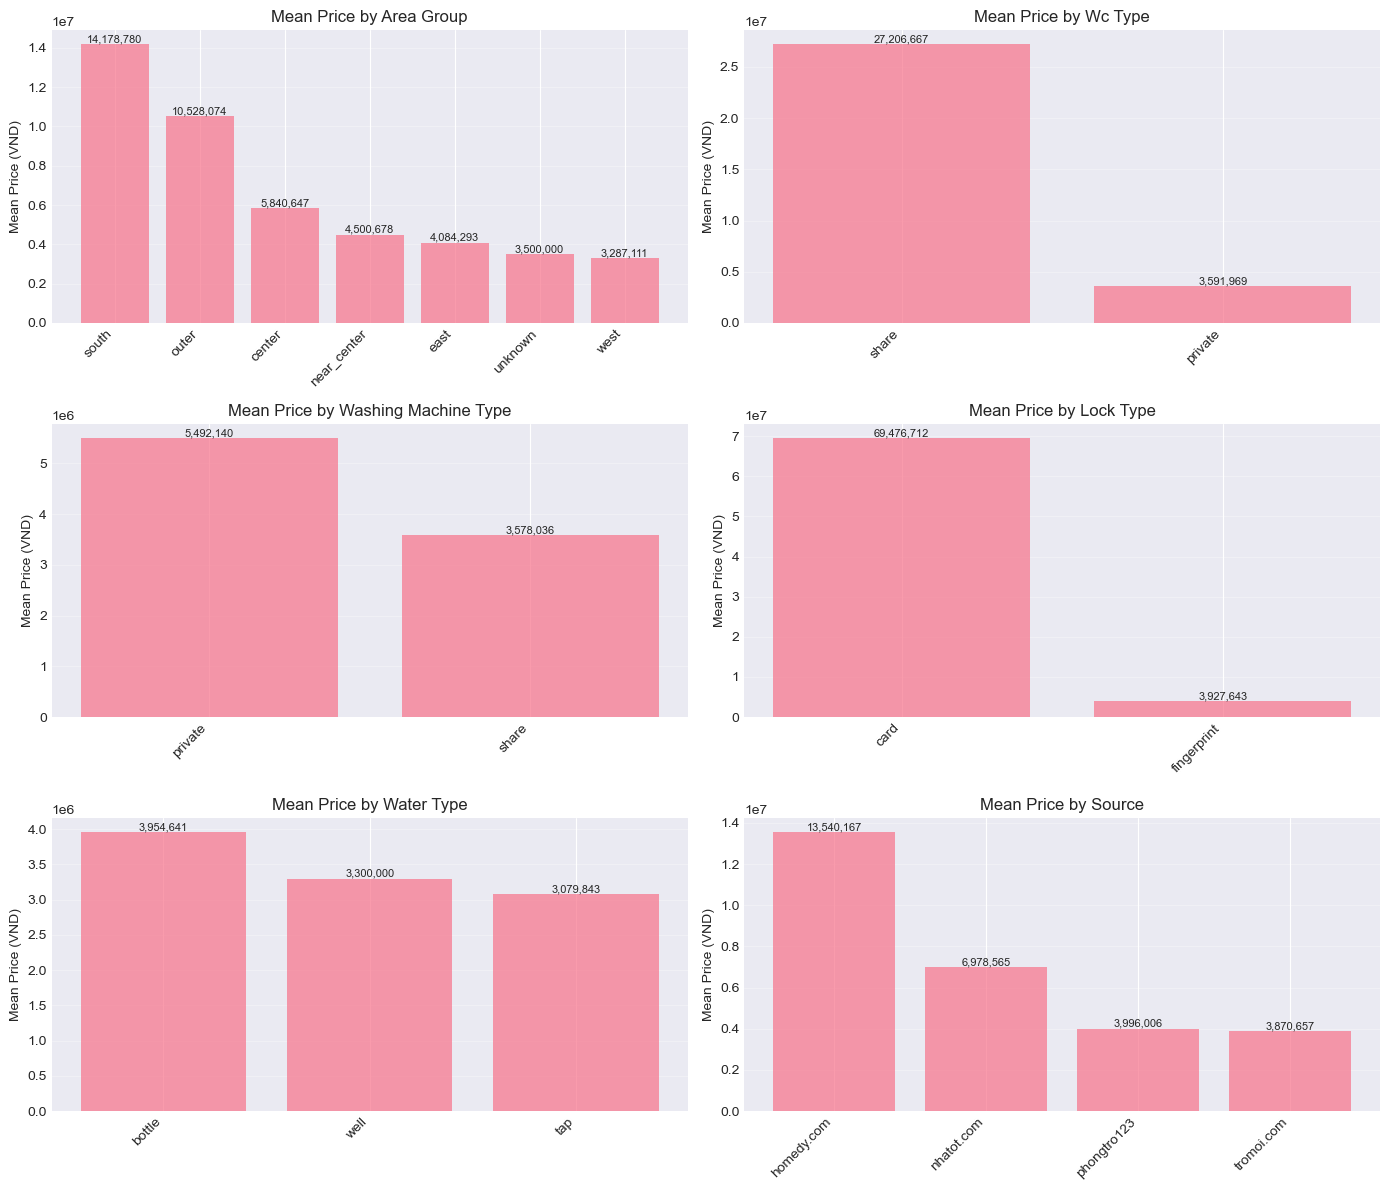

In [56]:
# Visualize categorical features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

viz_features = ['area_group', 'wc_type', 'washing_machine_type', 'lock_type', 'water_type', 'source']

for idx, col in enumerate(viz_features):
    if col in df.columns and idx < len(axes):
        valid_data = df[df[col].notna()]
        
        if len(valid_data) > 0:
            # Bar plot with price
            price_by_cat = valid_data.groupby(col)['price'].mean().sort_values(ascending=False)
            
            axes[idx].bar(range(len(price_by_cat)), price_by_cat.values, alpha=0.7)
            axes[idx].set_xticks(range(len(price_by_cat)))
            axes[idx].set_xticklabels(price_by_cat.index, rotation=45, ha='right')
            axes[idx].set_ylabel('Mean Price (VND)')
            axes[idx].set_title(f'Mean Price by {col.replace("_", " ").title()}')
            axes[idx].grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for i, v in enumerate(price_by_cat.values):
                axes[idx].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Binary Features Analysis

In [57]:
# Analyze binary features
print("="*70)
print("BINARY FEATURES ANALYSIS")
print("="*70)

# Calculate prevalence and price impact
binary_analysis = []

for col in binary_cols:
    if col in df.columns:
        prevalence = df[col].sum() / len(df) * 100
        
        # Calculate price difference
        price_with = df[df[col] == True]['price'].mean()
        price_without = df[df[col] == False]['price'].mean()
        price_diff = price_with - price_without
        price_diff_pct = (price_diff / price_without * 100) if price_without > 0 else 0
        
        binary_analysis.append({
            'Feature': col,
            'Prevalence (%)': prevalence,
            'Price with': price_with,
            'Price without': price_without,
            'Price Diff': price_diff,
            'Price Diff (%)': price_diff_pct
        })

binary_df = pd.DataFrame(binary_analysis).sort_values('Price Diff (%)', ascending=False)

print("\n📊 Top 15 Binary Features by Price Impact:")
print(binary_df.head(15)[['Feature', 'Prevalence (%)', 'Price Diff', 'Price Diff (%)']].to_string(index=False))

print("\n\n📊 Bottom 10 Binary Features by Price Impact:")
print(binary_df.tail(10)[['Feature', 'Prevalence (%)', 'Price Diff', 'Price Diff (%)']].to_string(index=False))

BINARY FEATURES ANALYSIS

📊 Top 15 Binary Features by Price Impact:
          Feature  Prevalence (%)  Price Diff  Price Diff (%)
 near_supermarket           13.58  3058537.80           52.53
      has_balcony           22.21  1756589.46           30.04
      near_school           35.17  -658506.72          -10.18
         has_sofa            1.72 -1020912.18          -16.32
      near_market           15.21 -1557958.60          -24.06
        is_duplex           29.13 -2053545.43          -30.04
          has_bed           18.99 -2609717.84          -38.76
     has_wardrobe           19.30 -2647524.58          -39.23
       has_fridge           21.58 -2759921.37          -40.39
     has_mattress           15.15 -2704223.36          -40.68
       has_window           28.77 -2910886.93          -41.15
      has_parking           24.02 -3060372.25          -43.89
       has_camera           24.55 -3090205.85          -44.17
is_full_furniture           52.80 -3699399.06          -45.16
  

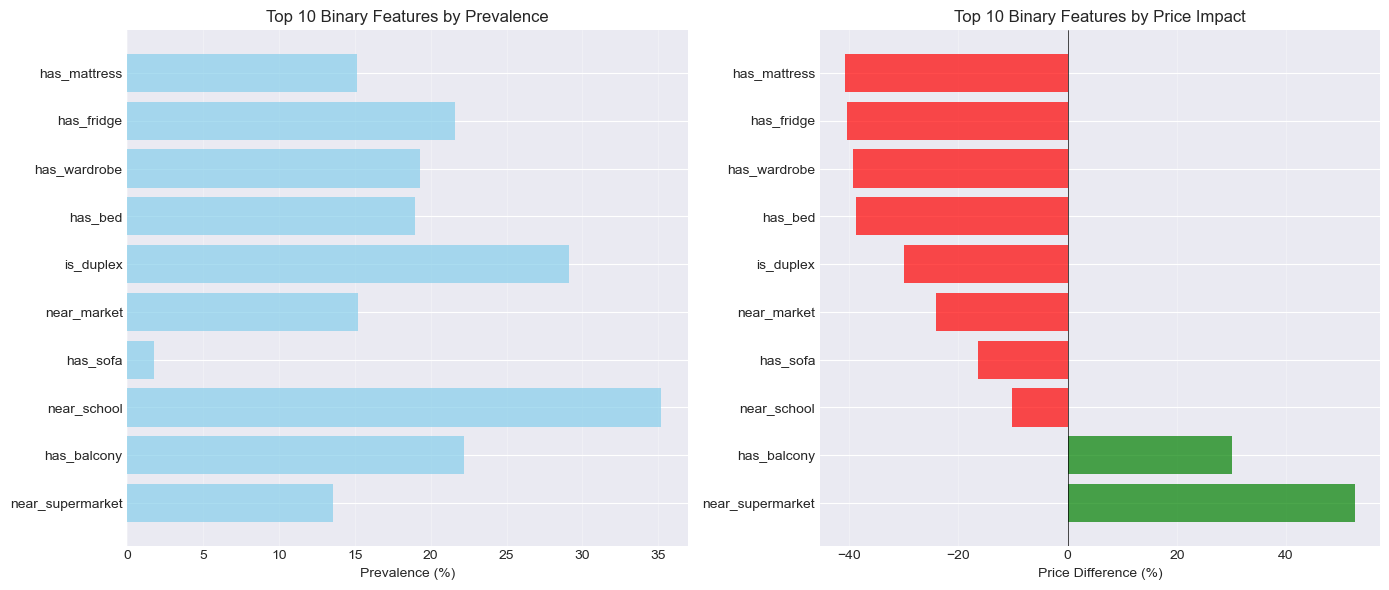

In [58]:
# Visualize top binary features impact
top_features = binary_df.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prevalence
axes[0].barh(range(len(top_features)), top_features['Prevalence (%)'].values, alpha=0.7, color='skyblue')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'].values)
axes[0].set_xlabel('Prevalence (%)')
axes[0].set_title('Top 10 Binary Features by Prevalence')
axes[0].grid(True, alpha=0.3, axis='x')

# Price impact
colors = ['green' if x > 0 else 'red' for x in top_features['Price Diff (%)'].values]
axes[1].barh(range(len(top_features)), top_features['Price Diff (%)'].values, alpha=0.7, color=colors)
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['Feature'].values)
axes[1].set_xlabel('Price Difference (%)')
axes[1].set_title('Top 10 Binary Features by Price Impact')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 6. Missing Data Analysis & Strategy

MISSING DATA ANALYSIS

Features with missing data: 13

               Feature  Missing Count  Missing (%) Data Type
               wc_type          30255        87.28    object
            water_type          27708        79.94    object
 mention_service_price          27121        78.24    object
  washing_machine_type          24636        71.07    object
             lock_type          23318        67.27    object
           posted_time          22669        65.40    object
            owner_name          22669        65.40    object
                 phone          22669        65.40   float64
mention_electric_price          22633        65.29    object
   mention_water_price          21357        61.61    object
                  ward           1575         4.54    object
                 price             54         0.16   float64
                  area              2         0.01   float64


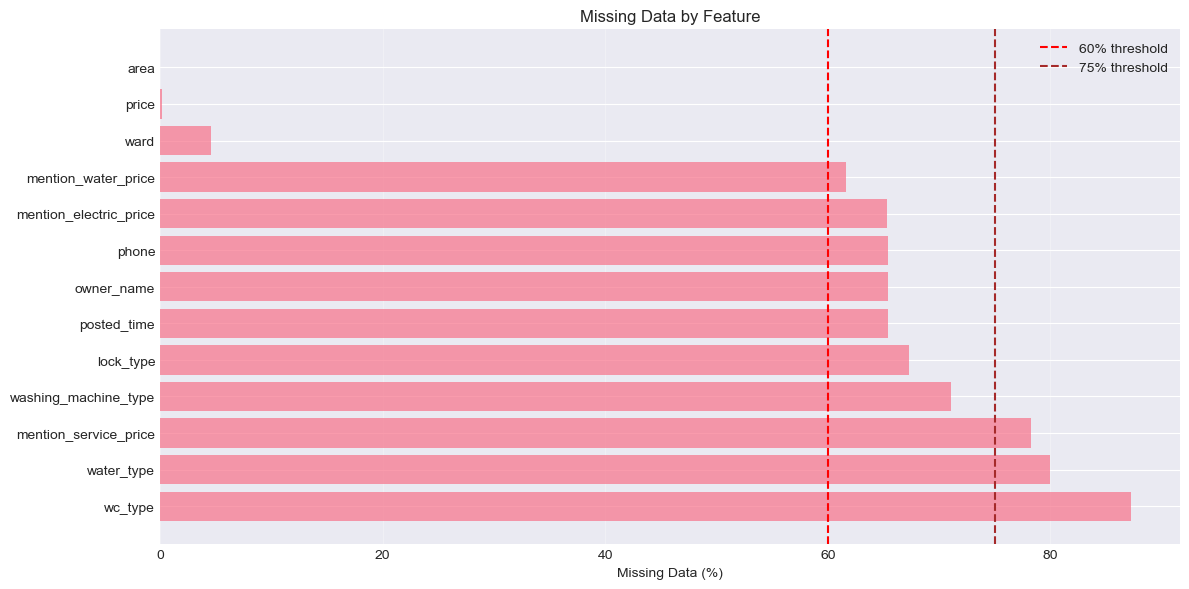

In [59]:
# Comprehensive missing data analysis
print("="*70)
print("MISSING DATA ANALYSIS")
print("="*70)

missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        missing_pct = missing_count / len(df) * 100
        missing_data.append({
            'Feature': col,
            'Missing Count': missing_count,
            'Missing (%)': missing_pct,
            'Data Type': df[col].dtype
        })


missing_df = pd.DataFrame(missing_data).sort_values('Missing (%)', ascending=False)

print(f"\nFeatures with missing data: {len(missing_df)}")
print("\n" + missing_df.to_string(index=False))

# Visualize missing data
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(missing_df)), missing_df['Missing (%)'].values, alpha=0.7)
    plt.yticks(range(len(missing_df)), missing_df['Feature'].values)
    plt.xlabel('Missing Data (%)')
    plt.title('Missing Data by Feature')
    plt.axvline(x=60, color='red', linestyle='--', label='60% threshold')
    plt.axvline(x=75, color='brown', linestyle='--', label='75% threshold')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

**Chiến thuật xử lí các cột bị thiếu trên 60%**
- Đối với cột **phone**, **owner_name**, **posted_time**: đây là các cột ít có giá trị, **posted_time** đều ở trong năm 2025 nên chênh lệch giá theo thời gian không có, do đó ta sẽ bỏ 3 cột này, 3 cột này sẽ được bỏ cùng lúc bỏ các cột không cần thiết như url, address, description (sau khi triết xuất thông tin)
- Đối với cột **mention_electric_price**,**mention_water_price**,**mention_service_price**: ta thấy giá nước và giá điện được đề cập 40%, tuy nhiên thực tế khi chủ trọ muốn cho thông tin giá điện, nước thì cũng sẽ cho giá dịch vụ **mention_service_price**, việc **mention_electric_price**, **mention_water_price** chỉ gần 70% là chưa chính xác vì có thể các từ làm nhiễu như điện thoại, xe điệp, đồng hồ nước riêng đã làm đẹp chỉ số lên, do đó, thực tế số tiền điện, nước, dịch vụ được đề cập thiếu gần 80%, đây là một chiến thuật của chủ trọ nhằm giấu thông tin xấu để thu hút thêm nhiều khách tìm trọ chủ động nhắn để có thể thuyết phục, do đó em cũng sẽ bỏ 3 cột này.
- Đối với cột **wc_type**,**water_type**,**washing_machine_type**,**lock_type**: em nghĩ nó có giá trị vì đây là nhưng thông tin mà chủ trọ sẽ đăng nhằm tăng sự hấp dẫn đối với người tìm trọ, nên chủ trọ sẽ không giấu, do đó thông tin ở các cột này chính xác.


In [68]:
missing_col=['mention_electric_price','mention_water_price','mention_service_price']

## 7. Duplicate Detection & Data Cleaning

**Strategy based on analysis (with improvements):**
1. Detect and remove exact duplicates
2. Detect and remove near-duplicates (spam/reposted listings)
3. Remove rows with missing target (price)
4. Handle outliers in price **using data-driven thresholds (IQR + quantiles), không hard-code ngưỡng theo domain knowledge**
5. Handle outliers in area **cũng bằng ngưỡng tự tính từ dữ liệu**
6. Clean & impute utility prices với **ngưỡng theo phân vị từng cột**, thay vì fix cứng
7. Handle categorical missing values (impute / tạo nhóm 'unknown' hoặc drop nếu là thông tin bắt buộc)
8. Remove text columns (not needed for baseline tabular modeling)


In [69]:
# Create a copy for cleaning
df_clean = df.copy()

print("="*70)
print("DATA CLEANING PROCESS")
print("="*70)

# Step 0: Detect and remove exact duplicates
initial_rows = len(df_clean)
exact_dupes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"\n0️⃣  Removed {exact_dupes:,} exact duplicate rows")
print(f"   Remaining: {len(df_clean):,} rows")

# Step 0.5: Detect and remove near-duplicates (spam detection)
# Near-duplicate: same ward + same price + same area + same street + same district
print(f"\n🔍 Detecting near-duplicates (spam posts)...")
near_dup_cols = ['ward', 'price', 'area','street','district']
before_spam = len(df_clean)

# Keep first occurrence, mark rest as duplicates
spam_mask = df_clean.duplicated(subset=near_dup_cols, keep='first')
spam_count = spam_mask.sum()

if spam_count > 0:
    print(f"   Found {spam_count:,} potential spam/reposted listings")
    print(f"   Example spam patterns:")
    spam_examples = df_clean[spam_mask][near_dup_cols].head(5)
    for idx, row in spam_examples.iterrows():
        print(f"      • Quận {row['district']} Phường {row['ward']} Đường {row['street']} | {row['price']:,.0f} VND | {row['area']:.0f}m²")
    
    df_clean = df_clean[~spam_mask]
    print(f"\n0️⃣.5 Removed {spam_count:,} near-duplicate/spam rows")
    print(f"   Remaining: {len(df_clean):,} rows")


# Step 1: Remove rows with missing price (target variable)
before_price = len(df_clean)
df_clean = df_clean[df_clean['price'].notna()]
print(f"\n1️⃣  Removed {before_price - len(df_clean):,} rows with missing price")
print(f"   Remaining: {len(df_clean):,} rows")

# Step 2: Handle price outliers (data-driven thresholds instead of hard-coded domain range)
# Use robust IQR + quantile-based bounds so that thresholds adapt to the dataset
price_series = df_clean['price'].dropna()

if len(price_series) > 0:
    # Basic quantile range
    q1, q3 = price_series.quantile([0.25, 0.75])
    iqr = q3 - q1

    # IQR-based bounds (more lenient upper bound to keep rare-but-valid high prices)
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 3.0 * iqr

    # Clip to 1st–99th percentile to avoid extreme tails driving the bounds
    p1, p99 = price_series.quantile([0.01, 0.99])
    lower_bound = max(iqr_lower, p1)
    upper_bound = min(iqr_upper, p99)

    before_outlier = len(df_clean)
    df_clean = df_clean[(df_clean['price'] >= lower_bound) & (df_clean['price'] <= upper_bound)]
    removed = before_outlier - len(df_clean)
    print(f"\n2️⃣  Removed {removed:,} price outliers outside [{lower_bound:,.0f}, {upper_bound:,.0f}] VND")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("\n2️⃣  Skipped price outlier handling (no non-null price values)")

# Step 3: Handle area outliers (also data-driven)
area_series = df_clean['area'].dropna()

if len(area_series) > 0:
    a_q1, a_q3 = area_series.quantile([0.25, 0.75])
    a_iqr = a_q3 - a_q1

    a_iqr_lower = a_q1 - 1.5 * a_iqr
    a_iqr_upper = a_q3 + 3.0 * a_iqr

    a_p1, a_p99 = area_series.quantile([0.01, 0.99])
    area_lower = max(a_iqr_lower, a_p1)
    area_upper = min(a_iqr_upper, a_p99)

    before_area = len(df_clean)
    df_clean = df_clean[(df_clean['area'] >= area_lower) & (df_clean['area'] <= area_upper)]
    removed_area = before_area - len(df_clean)
    print(f"\n3️⃣  Removed {removed_area:,} area outliers outside [{area_lower:.1f}, {area_upper:.1f}] m²")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("\n3️⃣  Skipped area outlier handling (no non-null area values)")




# Step 6: Handle categorical missing values
print(f"\n6️⃣  Handling categorical missing values:")

# For categorical features with high missing rate, create 'unknown' category
cat_to_fill = ['washing_machine_type', 'wc_type', 'lock_type', 'water_type']
for col in cat_to_fill:
    if col in df_clean.columns:
        missing_count = df_clean[col].isnull().sum()
        if missing_count > 0:
            df_clean[col].fillna('unknown', inplace=True)
            print(f"   {col}: filled {missing_count:,} with 'unknown'")

# For area_group, district - drop rows with missing (location is important)
location_cols = ['area_group', 'district']
for col in location_cols:
    if col in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean[df_clean[col].notna()]
        removed = before - len(df_clean)
        if removed > 0:
            print(f"   {col}: removed {removed:,} rows with missing values")

# Summary
total_removed = initial_rows - len(df_clean)
print(f"\n{'='*70}")
print(f"✅ Cleaning complete!")
print(f"{'='*70}")
print(f"   Original dataset: {initial_rows:,} rows")
print(f"   Final dataset: {len(df_clean):,} rows × {df_clean.shape[1]} columns")
print(f"   Total removed: {total_removed:,} rows ({total_removed/initial_rows*100:.2f}%)")
print(f"   Retention rate: {len(df_clean)/initial_rows*100:.2f}%")

DATA CLEANING PROCESS

0️⃣  Removed 69 exact duplicate rows
   Remaining: 34,594 rows

🔍 Detecting near-duplicates (spam posts)...
   Found 4,930 potential spam/reposted listings
   Example spam patterns:
      • Quận gò vấp Phường 17 Đường 5 | 4,400,000 VND | 35m²
      • Quận phú nhuận Phường 2 Đường phan xích long | 5,500,000 VND | 35m²
      • Quận bình tân Phường tân tạo Đường xa lộ đại hàn | 500,000 VND | 20m²
      • Quận bình thạnh Phường 21 Đường xô viết nghệ tĩnh | 950,000 VND | 20m²
      • Quận 6 Phường 10 Đường an dương vương | 2,500,000 VND | 20m²

0️⃣.5 Removed 4,930 near-duplicate/spam rows
   Remaining: 29,664 rows

1️⃣  Removed 49 rows with missing price
   Remaining: 29,615 rows

2️⃣  Removed 502 price outliers outside [1,000,000, 9,000,000] VND
   Remaining: 29,113 rows

3️⃣  Removed 559 area outliers outside [10.0, 60.0] m²
   Remaining: 28,554 rows

6️⃣  Handling categorical missing values:
   washing_machine_type: filled 20,455 with 'unknown'
   wc_type: filled 2

### Improvement Notes: Outlier Handling
In this version, the **outlier handling for `price`, `area`, and utility cost columns** has been adjusted:

- Instead of using fixed thresholds like `500k–30M`, `5–200m²`, `1,000–1,000,000` (based purely on domain knowledge),  
  we now use **data-driven thresholds automatically derived from the data**:
  - Combining **IQR (Q1, Q3)** and **1st–99th percentiles** to determine reasonable price/area ranges.
  - These thresholds **adapt to the dataset** (different cities, time periods, market segments) without requiring code changes.
- Columns like `electric_price`, `water_price`, etc. are also cleaned using **column-specific 1st–99th percentile bounds**,
  rather than applying a fixed range universally.

This approach provides:
- A more **generalizable pipeline** that's easier to reuse for different datasets.
- Avoids excessive dependence on analyst-chosen thresholds based on intuition.


In [70]:
# Verify cleaning results
print("="*70)
print("POST-CLEANING VALIDATION")
print("="*70)

print(f"\n📊 Dataset shape: {df_clean.shape}")
print(f"\n💰 Price statistics:")
print(df_clean['price'].describe())

print(f"\n📏 Area statistics:")
print(df_clean['area'].describe())

print(f"\n❌ Remaining missing values:")
remaining_missing = df_clean.isnull().sum()
if remaining_missing.sum() == 0:
    print("   ✅ No missing values!")
else:
    print(remaining_missing[remaining_missing > 0])

# Check data quality
print(f"\n✅ Data Quality Checks:")
print(f"   • All prices in valid range: {df_clean['price'].between(500000, 30000000).all()}")
print(f"   • All areas in valid range: {df_clean['area'].between(5, 200).all()}")
print(f"   • No missing target: {df_clean['price'].isnull().sum() == 0}")
print(f"   • No duplicates: {df_clean.duplicated().sum() == 0}")

POST-CLEANING VALIDATION

📊 Dataset shape: (28554, 40)

💰 Price statistics:
count     28554.00
mean    3888721.03
std     1443609.25
min     1000000.00
25%     2900000.00
50%     3800000.00
75%     4800000.00
max     9000000.00
Name: price, dtype: float64

📏 Area statistics:
count   28554.00
mean       26.56
std         8.32
min        10.00
25%        20.00
50%        25.00
75%        30.00
max        60.00
Name: area, dtype: float64

❌ Remaining missing values:
posted_time               18041
owner_name                18041
phone                     18041
ward                       1388
mention_electric_price    18621
mention_water_price       17631
mention_service_price     22333
dtype: int64

✅ Data Quality Checks:
   • All prices in valid range: True
   • All areas in valid range: True
   • No missing target: True
   • No duplicates: True


## 8. Feature Engineering & Selection

In [71]:
# Create new features
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

# 1. Price per square meter
df_clean['price_per_sqm'] = df_clean['price'] / df_clean['area']
print(f"\n✅ Created: price_per_sqm")

# 2. Total utility cost
# utility_price_cols = ['electric_price', 'water_price', 'garbage_price', 'service_price']
# df_clean['total_utility_cost'] = df_clean[utility_price_cols].sum(axis=1)
# print(f"✅ Created: total_utility_cost")

# 3. Amenities score (count of amenities)
amenity_cols = [col for col in binary_cols if col.startswith('has_')]
df_clean['amenity_score'] = df_clean[amenity_cols].sum(axis=1)
print(f"✅ Created: amenity_score (sum of {len(amenity_cols)} amenities)")

# 4. Location convenience score
location_cols = [col for col in binary_cols if col.startswith('near_')]
df_clean['location_score'] = df_clean[location_cols].sum(axis=1)
print(f"✅ Created: location_score (sum of {len(location_cols)} proximity features)")

# 5. Has private facilities flag
if 'wc_type' in df_clean.columns and 'washing_machine_type' in df_clean.columns:
    df_clean['has_private_facilities'] = (
        (df_clean['wc_type'] == 'private') & 
        (df_clean['washing_machine_type'] == 'private')
    ).astype(int)
    print(f"✅ Created: has_private_facilities")

# 6. Security score
security_features = ['has_camera', 'has_security', 'lock_type']
security_score = 0
if 'has_camera' in df_clean.columns:
    security_score += df_clean['has_camera'].astype(int)
if 'has_security' in df_clean.columns:
    security_score += df_clean['has_security'].astype(int)
if 'lock_type' in df_clean.columns:
    security_score += (df_clean['lock_type'].isin(['fingerprint', 'card'])).astype(int)

df_clean['security_score'] = security_score
print(f"✅ Created: security_score")

print(f"\n📊 New feature statistics:")
new_features = ['price_per_sqm', 'amenity_score', 'location_score', 'security_score']
print(df_clean[new_features].describe())

FEATURE ENGINEERING

✅ Created: price_per_sqm
✅ Created: amenity_score (sum of 13 amenities)
✅ Created: location_score (sum of 3 proximity features)
✅ Created: has_private_facilities
✅ Created: security_score

📊 New feature statistics:
       price_per_sqm  amenity_score  location_score  security_score
count       28554.00       28554.00        28554.00        28554.00
mean       152547.56           3.27            0.63            1.08
std         52569.18           2.51            0.73            1.02
min         16666.67           0.00            0.00            0.00
25%        120000.00           1.00            0.00            0.00
50%        150000.00           3.00            0.00            1.00
75%        182857.14           5.00            1.00            2.00
max        800000.00          13.00            3.00            3.00


### Log-transform target (price)

Since the `price` distribution is significantly right-skewed, we introduce a log-transformed target variable to assist linear models:

- `log_price = log1p(price)`  
  - Reduces the influence of extreme values.
  - Results in a distribution closer to normal, improving model stability regarding relative errors.


In [72]:
# Create log-transformed target
df_clean['log_price'] = np.log1p(df_clean['price'])

print("\n✅ Created: log_price (log1p of price)")
print("\n📊 log_price summary:")
print(df_clean['log_price'].describe())



✅ Created: log_price (log1p of price)

📊 log_price summary:
count   28554.00
mean       15.10
std         0.41
min        13.82
25%        14.88
50%        15.15
75%        15.38
max        16.01
Name: log_price, dtype: float64


### Correlation between key features and (log_)price

To quantify the observations from the EDA section, we quickly calculate the Pearson correlation coefficient between some engineered features and both `price` and `log_price`.


In [73]:
# Compute correlation with price and log_price for selected features
corr_features = ['area', 'price_per_sqm', 'amenity_score', 'location_score', 'security_score', 'total_utility_cost']
targets = ['price', 'log_price']

available_feats = [f for f in corr_features if f in df_clean.columns]
available_targets = [t for t in targets if t in df_clean.columns]

corr_results = {}

for t in available_targets:
    corr_results[t] = df_clean[available_feats + [t]].corr()[t].drop(t)

print("\n📊 Correlation with target variables:")
for t in available_targets:
    print(f"\n=== Correlation with {t} ===")
    print(corr_results[t].sort_values(ascending=False))



📊 Correlation with target variables:

=== Correlation with price ===
price_per_sqm     0.58
area              0.46
amenity_score     0.09
security_score    0.03
location_score   -0.07
Name: price, dtype: float64

=== Correlation with log_price ===
price_per_sqm     0.60
area              0.42
amenity_score     0.09
security_score    0.03
location_score   -0.06
Name: log_price, dtype: float64


In [74]:
# Feature selection: remove unnecessary columns
print("="*70)
print("FEATURE SELECTION")
print("="*70)

# Columns to drop (text, URLs, redundant)
cols_to_drop = ['url', 'title', 'address', 'description', 'street', 'source','posted_time', 'owner_name', 'phone']

# Drop text columns
df_final = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

print(f"\n✅ Dropped {len([col for col in cols_to_drop if col in df_clean.columns])} text/redundant columns")
print(f"\n📊 Final dataset shape: {df_final.shape}")

# Show final feature list
print(f"\n📋 Final features ({df_final.shape[1]} total):")
print(f"\n   Target variable:")
print(f"      • price")

print(f"\n   Numerical features ({len([c for c in df_final.columns if df_final[c].dtype in ['float64', 'int64'] and c != 'price'])}):")
numeric_features = [c for c in df_final.columns if df_final[c].dtype in ['float64', 'int64'] and c != 'price']
for feat in sorted(numeric_features):
    print(f"      • {feat}")

print(f"\n   Categorical features ({len([c for c in df_final.columns if df_final[c].dtype == 'object'])}):")
cat_features = [c for c in df_final.columns if df_final[c].dtype == 'object']
for feat in sorted(cat_features):
    unique_count = df_final[feat].nunique()
    print(f"      • {feat} ({unique_count} categories)")

print(f"\n   Binary features ({len([c for c in df_final.columns if df_final[c].dtype == 'bool'])}):")
binary_features = [c for c in df_final.columns if df_final[c].dtype == 'bool']
print(f"      {len(binary_features)} boolean features (has_*, near_*)")

FEATURE SELECTION

✅ Dropped 9 text/redundant columns

📊 Final dataset shape: (28554, 37)

📋 Final features (37 total):

   Target variable:
      • price

   Numerical features (5):
      • amenity_score
      • area
      • location_score
      • log_price
      • price_per_sqm

   Categorical features (10):
      • area_group (7 categories)
      • district (24 categories)
      • lock_type (3 categories)
      • mention_electric_price (1 categories)
      • mention_service_price (1 categories)
      • mention_water_price (1 categories)
      • ward (163 categories)
      • washing_machine_type (3 categories)
      • water_type (4 categories)
      • wc_type (3 categories)

   Binary features (19):
      19 boolean features (has_*, near_*)


### 🔍 Improved Feature Selection

To be clearer and more scientific:
- **Separate target** from the input feature list
- **Remove near-constant numeric columns** (very few distinct values → no information)
- Note based on EDA results: will **keep most features** to evaluate using model-based selection later


In [75]:
# Separate target vs input features
target_cols = ['price', 'log_price']
existing_targets = [c for c in target_cols if c in df_final.columns]

print("\n🎯 Target columns:", existing_targets)

# Identify numeric input features only
numeric_inputs = [c for c in df_final.columns 
                  if df_final[c].dtype in ['float64', 'int64'] and c not in existing_targets]

# Drop near-constant features (very low variance)
low_var_cols = [c for c in numeric_inputs if df_final[c].nunique() <= 2]
# Explanation: nếu một feature numeric lại chỉ có <=2 giá trị khác nhau thì nó không có đóng góp nhiều

if low_var_cols:
    print("\n⚠️ Dropping near-constant numeric features:", low_var_cols)
    df_final = df_final.drop(columns=low_var_cols)
else:
    print("\n👍 No low-information numeric features found")

df_final=df_final.drop(columns=missing_col)
print("\n⚠️ Dropping not trushworthy features:", missing_col)

print("\n📌 Final feature count:", len(df_final.columns))
print("Examples:", df_final.columns[:10].tolist(), "...")


🎯 Target columns: ['price', 'log_price']

👍 No low-information numeric features found

⚠️ Dropping not trushworthy features: ['mention_electric_price', 'mention_water_price', 'mention_service_price']

📌 Final feature count: 34
Examples: ['price', 'area', 'district', 'ward', 'has_air_conditioner', 'has_kitchen', 'has_fridge', 'has_wardrobe', 'has_bed', 'has_mattress'] ...


## 9. Final Data Validation & Export

In [76]:
# Final comprehensive validation
print("="*70)
print("FINAL DATA VALIDATION")
print("="*70)

print(f"\n📊 Dataset Overview:")
print(f"   • Total records: {len(df_final):,}")
print(f"   • Total features: {df_final.shape[1]}")
print(f"   • Memory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n✅ Data Quality:")
print(f"   • Missing values: {df_final.isnull().sum().sum()}")
print(f"   • Duplicate rows: {df_final.duplicated().sum()}")
print(f"   • Price range: [{df_final['price'].min():,.0f}, {df_final['price'].max():,.0f}] VND")
print(f"   • Area range: [{df_final['area'].min():.1f}, {df_final['area'].max():.1f}] m²")

print(f"\n📈 Target Variable (Price):")
print(f"   • Mean: {df_final['price'].mean():,.0f} VND")
print(f"   • Median: {df_final['price'].median():,.0f} VND")
print(f"   • Std Dev: {df_final['price'].std():,.0f} VND")
print(f"   • CV: {(df_final['price'].std() / df_final['price'].mean() * 100):.1f}%")

# Data reduction summary
print(f"\n📉 Data Cleaning Summary:")
print(f"   • Original dataset: {len(df):,} rows")
print(f"   • Final dataset: {len(df_final):,} rows")
print(f"   • Removed: {len(df) - len(df_final):,} rows ({(len(df) - len(df_final))/len(df)*100:.2f}%)")
print(f"   • Retention rate: {len(df_final)/len(df)*100:.2f}%")

# Check data distribution stability
print(f"\n🔍 Data Quality Indicators:")
print(f"   • Unique addresses: {df_final['address'].nunique() if 'address' in df_final.columns else 'N/A'}")
print(f"   • Unique districts: {df_final['district'].nunique() if 'district' in df_final.columns else 'N/A'}")
print(f"   • Price-to-area ratio range: [{(df_final['price']/df_final['area']).min():,.0f}; {(df_final['price']/df_final['area']).max():,.0f}] VND/m²")

print(f"\n✅ Dataset is clean and ready for modeling!")

FINAL DATA VALIDATION

📊 Dataset Overview:
   • Total records: 28,554
   • Total features: 34
   • Memory usage: 15.46 MB

✅ Data Quality:
   • Missing values: 1388
   • Duplicate rows: 96
   • Price range: [1,000,000, 9,000,000] VND
   • Area range: [10.0, 60.0] m²

📈 Target Variable (Price):
   • Mean: 3,888,721 VND
   • Median: 3,800,000 VND
   • Std Dev: 1,443,609 VND
   • CV: 37.1%

📉 Data Cleaning Summary:
   • Original dataset: 34,663 rows
   • Final dataset: 28,554 rows
   • Removed: 6,109 rows (17.62%)
   • Retention rate: 82.38%

🔍 Data Quality Indicators:
   • Unique addresses: N/A
   • Unique districts: 24
   • Price-to-area ratio range: [16,667; 800,000] VND/m²

✅ Dataset is clean and ready for modeling!


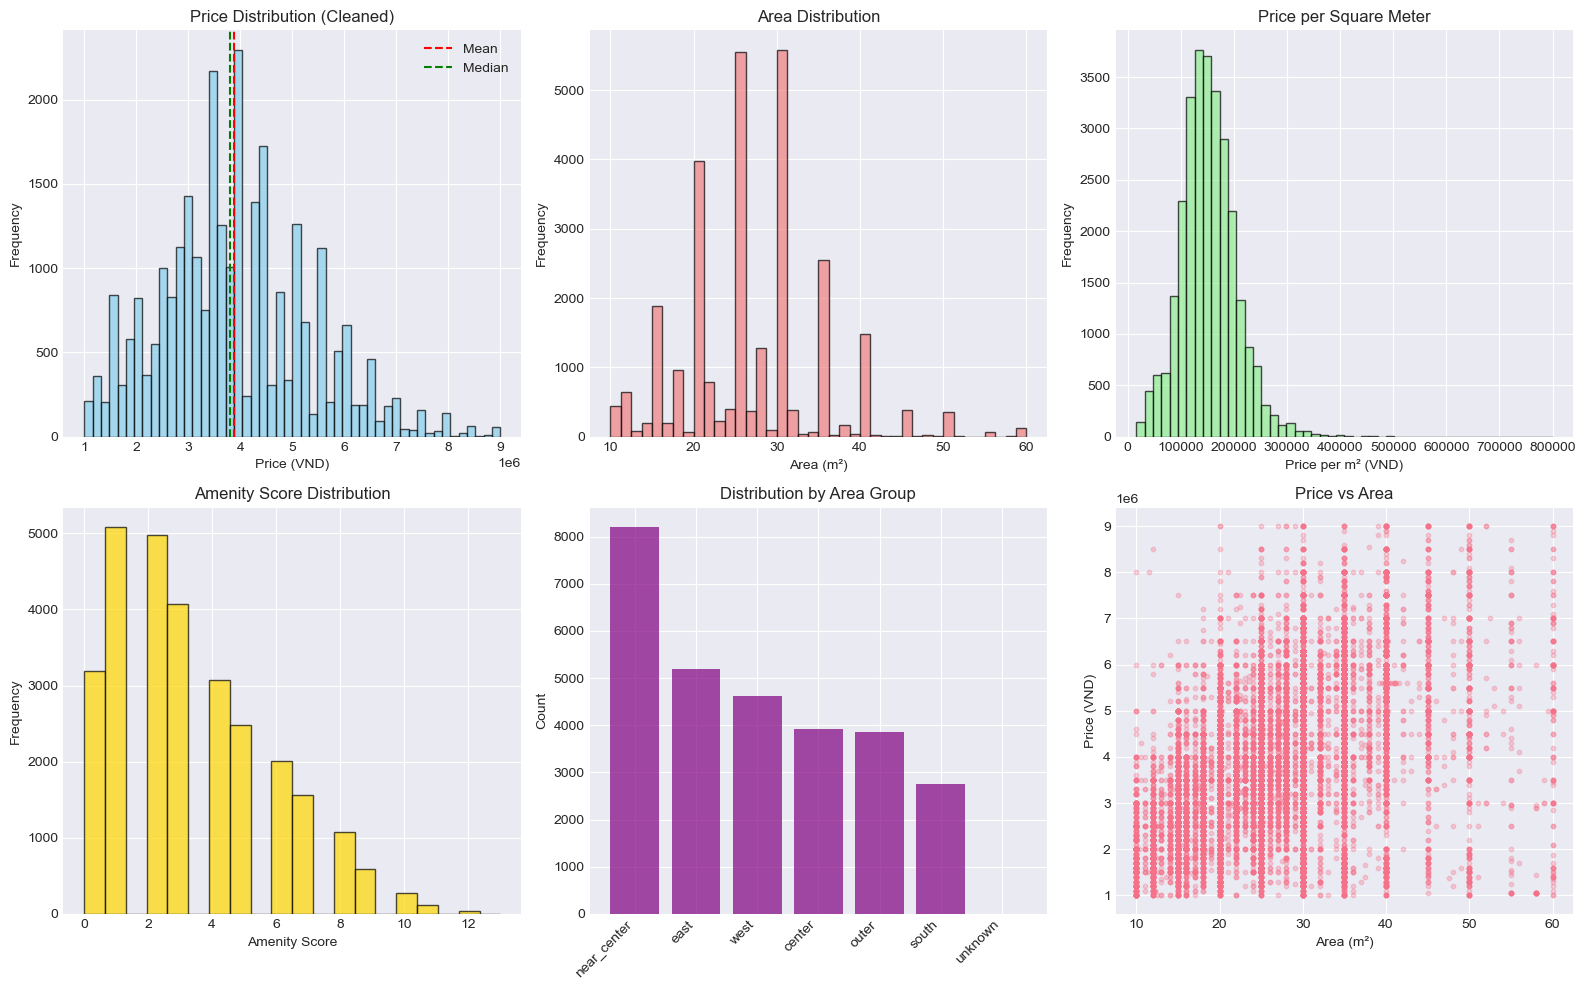

In [77]:
# Visualize final data distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Price distribution (cleaned)
axes[0, 0].hist(df_final['price'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Price (VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution (Cleaned)')
axes[0, 0].axvline(df_final['price'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].axvline(df_final['price'].median(), color='green', linestyle='--', label='Median')
axes[0, 0].legend()

# 2. Area distribution
axes[0, 1].hist(df_final['area'], bins=40, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_xlabel('Area (m²)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Area Distribution')

# 3. Price per sqm
axes[0, 2].hist(df_final['price_per_sqm'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 2].set_xlabel('Price per m² (VND)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Price per Square Meter')

# 4. Amenity score
axes[1, 0].hist(df_final['amenity_score'], bins=20, edgecolor='black', alpha=0.7, color='gold')
axes[1, 0].set_xlabel('Amenity Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Amenity Score Distribution')

# 5. Area group
if 'area_group' in df_final.columns:
    area_counts = df_final['area_group'].value_counts()
    axes[1, 1].bar(range(len(area_counts)), area_counts.values, alpha=0.7, color='purple')
    axes[1, 1].set_xticks(range(len(area_counts)))
    axes[1, 1].set_xticklabels(area_counts.index, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Distribution by Area Group')

# 6. Price vs Area scatter
axes[1, 2].scatter(df_final['area'], df_final['price'], alpha=0.3, s=10)
axes[1, 2].set_xlabel('Area (m²)')
axes[1, 2].set_ylabel('Price (VND)')
axes[1, 2].set_title('Price vs Area')

plt.tight_layout()
plt.show()

In [78]:
# Export cleaned data
output_path = '../../data/processed/data_clean.csv'
df_final.to_csv(output_path, index=False)

print("="*70)
print("DATA EXPORT COMPLETE")
print("="*70)
print(f"\n✅ Cleaned data saved to: {output_path}")
print(f"📊 Shape: {df_final.shape}")
print(f"💾 File size: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n🎯 Dataset is ready for modeling!")
print(f"\n📋 Next steps:")
print(f"   1. Split data into train/test sets")
print(f"   2. Encode categorical variables")
print(f"   3. Scale numerical features")
print(f"   4. Build and evaluate models")

DATA EXPORT COMPLETE

✅ Cleaned data saved to: ../../data/processed/data_clean.csv
📊 Shape: (28554, 34)
💾 File size: 15.46 MB

🎯 Dataset is ready for modeling!

📋 Next steps:
   1. Split data into train/test sets
   2. Encode categorical variables
   3. Scale numerical features
   4. Build and evaluate models


## Summary of EDA & Preprocessing

### Key Findings:
1. **Dataset**: ~34k listings, sau khi loại trùng lặp, spam và outlier còn một tập dữ liệu sạch cho modeling
2. **Target Variable**: `price` có phân phối **lệch phải (right-skewed)**, đã bổ sung biến `log_price = log1p(price)` cho các mô hình tuyến tính
3. **Important Features** (theo tương quan và phân tích đơn biến):
   - **Area** (tương quan dương rõ với price)
   - **Area group / district** (vị trí ảnh hưởng mạnh đến mặt bằng giá)
   - **Amenities** (furniture, AC, tiện ích đi kèm)
   - **Security features**
   - **Utility costs** (electric, water, service, garbage)

### Data Quality Actions:
✅ Removed missing prices (target)  
✅ Removed exact & near-duplicate listings (spam / repost)  
✅ Handled outliers cho `price` và `area` bằng **ngưỡng tự động từ dữ liệu (IQR + quantile 1%–99%)**, không hard-code 500k–30M hay 5–200m²  
✅ Cleaned utility prices bằng **ngưỡng phân vị 1%–99% cho từng cột** và impute phần còn thiếu bằng median  
✅ Xử lý missing values cho biến phân loại (tạo nhóm `'unknown'` hoặc loại bỏ nếu là thông tin location bắt buộc)  
✅ Tạo các **feature mới**: `price_per_sqm`, `total_utility_cost`, `amenity_score`, `log_price`,…  
✅ Loại bỏ những text column không dùng trong baseline tabular model  

### Ready for Modeling:
- Tập dữ liệu đã **sạch, nhất quán và có thêm một số feature kỹ thuật**.
- Có thể bắt đầu thử các mô hình như: Linear/ElasticNet trên `log_price`, Random Forest / XGBoost / LightGBM trên feature tabular, hoặc thêm pipeline encoding + scaling cho các baseline model.
